# Advanced Topics in Machine Learning: Natural Language Processing

Authors: Jonatan Bella, Alessia Berarducci, Jonas Knupp, Tobias Erbacher

Before running the notebook, please perform the following tasks:
- The folders inside the [data directory on our Github](https://github.com/TobiasErbacher/adv_topics_nlp/tree/main/data) must be uploaded to the colab instance.
- Set the colab secrets
   - **OPENAI_API_KEY** must be a token from OpenAPI for the generation of the sentence embeddings in the dataset investigation part. This secret is not necessary if you use the pre-computed embeddings we uploaded to Google Drive. Per default the code uses the pre-computed embeddings.
   - **HUGGINGFACE_TOKEN** must be a token from Huggingface that allows access to the gated Llama 3.2 repositories.
   - **NGROK_AUTH_TOKEN** must be a token from ngrok that allows access to the ngrok service. This is only necessary for running the end-to-end question answering pipeline in a nice GUI (see Voice Chatting with Streamlit section).


Before we start, let's verify that this notebook is run on Colab and that a GPU is available.

In [ ]:
import os
RUNNING_ON_LOCAL_MACHINE = True if 'COLAB_GPU' not in os.environ else False

import torch
GPU_AVAILABLE = torch.cuda.is_available()

assert not RUNNING_ON_LOCAL_MACHINE
assert GPU_AVAILABLE

## Dataset Investigation

The dataset contains 33'955 flashcards designed to help medical students learn topics like anatomy, physiology, and pharmacology. As detailed in [this study](https://arxiv.org/pdf/2304.08247), the flashcards were processed using OpenAI's GPT-3.5-Turbo to create question-answer pairs. In general, flashcard questions and answers are concise and focused, given the limited space available for detailed information. Cards with images were excluded.

**Steps for the dataset investigation:**

1. **Initial Cleaning:**
   - Removed duplicate entries from the dataset.
   - Deleted rows where both the input and output were empty, or where either one of them was empty.

2. **Document Length Analysis:**
   - Plotted the distribution of document lengths (number of words) separately for input and output fields.

3. **Vocabulary Size Analysis:**
   - Measured the unique word count for each document and plotted the distribution for both input and output.

4. **Tokenization and Lemmatization with SpaCy:**
   - Used **SpaCy**, a natural language processing library, to tokenize and lemmatize the text in both the input and output.
   - Trained a **Word2Vec** model using this combined list of medical text tokens and test the embeddings using cosine similary.
   - Word Cloud Analysis of Tokens.
   - Vocabulary Grouwth Curve.
   - Top 20 Most Common Words in Inputs and Outputs.

5. **Vector Embedding Using openAI**
  - Creation of Embeddings
  - Dimensionality Reduction
  - Clustering

6. **Indexing and Searching**
   - Used Whoosh


First, the dataset is loaded as a pandas dataframe.

In [ ]:
import pandas as pd

df = pd.read_json("hf://datasets/medalpaca/medical_meadow_medical_flashcards/medical_meadow_wikidoc_medical_flashcards.json")
df = df.iloc[:, 1:]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The first five rows are inspected.

In [ ]:
df.head()

,input,output
0,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...
1,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...
2,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...
3,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca..."
4,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...


The number of flashcards is computed.

In [ ]:
# Number of documents
num_documents = len(df)
print(f"Number of flashcards: {num_documents}")

Number of flashcards: 33955


#### Initial cleaning

In [ ]:
# Check for missing values
print(df.isnull().sum())

input     0
output    0
dtype: int64


In [ ]:
print("Sample Inputs:")
print(df['input'].head())

print("\nSample Outputs:")
print(df['output'].head())

Sample Inputs:
0    What is the relationship between very low Mg2+...
1    What leads to genitourinary syndrome of menopa...
2    What does low REM sleep latency and experienci...
3    What are some possible causes of low PTH and h...
4    How does the level of anti-müllerian hormone r...
Name: input, dtype: object

Sample Outputs:
0    Very low Mg2+ levels correspond to low PTH lev...
1    Low estradiol production leads to genitourinar...
2    Low REM sleep latency and experiencing halluci...
3    PTH-independent hypercalcemia, which can be ca...
4    The level of anti-müllerian hormone is directl...
Name: output, dtype: object


Various statistics regarding the lengths of the questions and answers are calculated.

In [ ]:
df['input_length'] = df['input'].apply(len)
df['output_length'] = df['output'].apply(len)

print(df[['input_length', 'output_length']].describe())

       input_length  output_length
count  33955.000000   33955.000000
mean      92.404771     349.095597
std       36.270348     313.553229
min        0.000000       0.000000
25%       68.000000      94.000000
50%       87.000000     150.000000
75%      111.000000     654.000000
max      401.000000    1576.000000


Next, duplicate entries are investigated.

In [ ]:
duplicates_nr = df.duplicated(subset=['input', 'output']).sum()
print(f"Number of duplicate flashcards: {duplicates_nr}")

duplicates = df[df.duplicated(subset=['input', 'output'], keep=False)]

# Print out some duplicates
print("Sample duplicate flashcards:")
print(duplicates.head())

Number of duplicate flashcards: 427
Sample duplicate flashcards:
                                                  input  \
1486  What is the name of the surgical emergency tha...   
1487  What is the name of the surgical emergency tha...   
1520  What are lymphoblasts, and what is the signifi...   
1521  What are lymphoblasts, and what is the signifi...   
1650  What is Hemolytic uremic syndrome and what is ...   

                                                 output  input_length  \
1486  Midgut volvulus is a surgical emergency that c...           168   
1487  Midgut volvulus is a surgical emergency that c...           168   
1520  Lymphoblasts are immature lymphocytes. Positiv...           104   
1521  Lymphoblasts are immature lymphocytes. Positiv...           104   
1650  Hemolytic uremic syndrome is a condition that ...            93   

      output_length  
1486            165  
1487            165  
1520            203  
1521            203  
1650            158  


In [ ]:
# Remove duplicates
427/len(df)*100 #1.25%
#Comment: we discared around the 1.25% of the information because of duplicates.
df = df.drop_duplicates(subset=['input', 'output'])
print(f"Number of flashcards after removing duplicates: {len(df)}")

Number of flashcards after removing duplicates: 33528


Below one can see the statistics for the dataframe after removing the dupliates.

In [ ]:
# Display statistics
print(df[['input_length', 'output_length']].describe())

       input_length  output_length
count  33528.000000   33528.000000
mean      93.496898     353.384306
std       35.033287     313.092705
min        0.000000       0.000000
25%       69.000000      95.000000
50%       87.000000     153.000000
75%      111.000000     657.000000
max      401.000000    1576.000000


We used the descriptive statistics to identify rows where the length of either the input questions or output answers is zero. By filtering the dataset, we created two separate DataFrames:

1. **`empty_inputs`**: Contains rows where the input has zero length
2. **`empty_outputs`**: Contains rows where the output has zero length

This allows us to detect and investigate entries with empty or invalid input/output tokens.

In [ ]:
empty_inputs = df[df['input_length'] == 0].reset_index()
empty_outputs = df[df['output_length'] == 0]

print(empty_inputs.head())


   index input                                             output  \
0   4834        There seems to be an error in the question and...   
1  10355                                                            
2  18256        What is the name of the duct that drains the s...   
3  18258        What is the name of the duct that drains the s...   
4  19729        I'm sorry, but the given answer "Symmetric, we...   

   input_length  output_length  
0             0            207  
1             0              0  
2             0             84  
3             0             81  
4             0            258  


The following is an example where the input is empty but not the output.

In [ ]:
empty_inputs.iloc[5]["output"]

"I'm sorry, but the given question and answer cannot be rephrased into an open-ended question and answer pair. The answer provided is incomplete and does not provide enough information to answer the question. Primary dysmenorrhea is not known to occur at the midcycle of the menstrual cycle, but rather immediately prior to or during menstruation. Therefore, the question and answer pair as given is incorrect."

In [ ]:
df['input_empty'] = df['input'].str.strip().eq("")
df['output_empty'] = df['output'].str.strip().eq("")
print("Empty Input Fields:", df['input_empty'].sum())
print("Empty Output Fields:", df['output_empty'].sum())

Empty Input Fields: 7
Empty Output Fields: 1


We remove rows where either the input, the output, or both have a length equal to 0.

In [ ]:
# Remove rows where input_length, output_length, or both are 0
df = df[~((df['input_length'] == 0) | (df['output_length'] == 0))].reset_index(drop=True)

### SpaCy

The output has a broader range of word counts, with many documents being significantly longer than those in the input field. This suggests that outputs often contain more details compared to inputs. The input distribution is more concentrated around shorter lengths, likely because inputs are concise questions.

We chose to use SpaCy's **en_core_sci_md** model, which is specifically designed for medical text processing. This decision was based on its ability to handle medical terminology effectively while including lemmatization to standardize words, such as reducing singular and plural forms. Unlike general models, **en_core_sci_md** leverages domain-specific knowledge, ensuring that the meanings of medical terms are preserved during text processing.

Comparison of unique token counts with different tools:

- **NLTK**:  
  - Unique tokens in inputs: 16'153  
  - Unique tokens in outputs: 24'407  

- **SpaCy (en_core_web_sm)**:  
  - Number of unique words in inputs (spaCy): 14'763
  - Number of unique words in outputs (spaCy): 21'498

- **SpaCy (en_core_web_sm)** after lemmatization:  
  - Number of unique words in inputs after lemmatization: 12'702
  - Number of unique words in outputs after lemmatization: 18'116

*Vocabulary size after lemmatization: 15'343*

- **SpaCy (en_core_sci_md)** after lemmatization:  
  - Unique tokens in inputs: 12'101  
  - Unique tokens in outputs: 17'356  

SpaCy **en_core_sci_md** was adopted since it results in the smallest vocabulary size.

In [ ]:
!pip install scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz (119.1 MB)
  Preparing metadata (setup.py) ... done


  We performed both **tokenization** and **lemmatization**, where:
  
  - **Tokenization:** Split the text into individual tokens.
  - **Lemmatization:** Reduced words to their root forms.


We handled specific cases where certain tokens, like "α-methyldopa," "TMP-SMX," and similar terms, might not be properly recognized during tokenization by adding them as special cases to the tokenizer. Additionally, we applied preprocessing steps to protect hyphenated terms, chemical formulas, and medical abbreviations, ensuring they are retained and processed correctly.

In [ ]:
import spacy
from gensim.models import Word2Vec
import pandas as pd
import re

LOAD_FROM_FILE = False

if LOAD_FROM_FILE:
  df = pd.read_parquet('df_spacy.parquet')
else:
  nlp = spacy.load("en_core_sci_md")

  special_cases = [
    "TMP-SMX", "α-methyldopa", "H1-blockers",
    "CDKN2A", "2,4-DNP", "AB+","α-methyldopa."
  ]
  for case in special_cases:
      nlp.tokenizer.add_special_case(case, [{"ORTH": case}])

  def preprocess_with_spacy(text):
    if pd.isna(text):
        return []

    # to protect hyphenated terms and chemical formulas
    text = re.sub(r'(\w+)-(\w+)', r'\1_HYPHEN_\2', text)
    text = re.sub(r'(α|β|γ|δ)-?(\d*)', r'alpha\2', text)  # for protecting this greek letters, we can add more here
    text = re.sub(r'(\d+,\d+)-([A-Za-z]+)', r'\1_\2', text) # for chemical formulas and measurements

    doc = nlp(str(text).lower().strip())

    tokens = []
    for token in doc:
        if token.is_stop or len(token.text) <= 1:
            continue

        # hyphen terms handling
        if '_HYPHEN_' in token.text:
            compound_term = token.text.replace('_HYPHEN_', '-')
            tokens.append(compound_term)
            continue

        # so we keep terms that are: Regular words (alphabetic), Numbers or numeric-like terms, Chemical formulas , Medical abbreviations (uppercase terms like CDKN2A)
        if (token.is_alpha or
            token.like_num or
            bool(re.search(r'[A-Z0-9]', token.text)) or
            bool(re.search(r'[A-Z]{2,}', token.text))):

            if token.text.isupper() or bool(re.search(r'[0-9]', token.text)):
                tokens.append(token.text)
            else:
                tokens.append(token.lemma_)

    tokens = [token.strip() for token in tokens if token.strip()]

    return tokens

  # Apply the preprocessing with lemmatization
  df['question_tokens_spacy2'] = df['input'].apply(preprocess_with_spacy)
  df['answer_tokens_spacy2'] = df['output'].apply(preprocess_with_spacy)
  df.to_parquet('df_spacy.parquet')

/usr/local/lib/python3.10/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


We calculated the word counts for both the input questions and output answers and displayed their descriptive statistics.


In [ ]:
df['input_word_count'] = df['question_tokens_spacy2'].apply(len)
df['output_word_count'] = df['answer_tokens_spacy2'].apply(len)

# Display statistics
print(df[['input_word_count', 'output_word_count']].describe())

       input_word_count  output_word_count
count      33521.000000       33521.000000
mean           7.080785          29.191910
std            2.954252          25.641222
min            0.000000           0.000000
25%            5.000000           8.000000
50%            7.000000          13.000000
75%            9.000000          53.000000
max           36.000000         137.000000


From the analysis, a few cases were observed where the tokens were not properly identified. These cases are negligible and do not impact the overall results, as the tokenization process works effectively for the majority of the data.

In [ ]:
df[df['input_word_count']==0]

,input,output,input_length,output_length,input_empty,output_empty,question_tokens_spacy2,answer_tokens_spacy2,input_word_count,output_word_count
12172,What is the brand-name for TMP-SMX (trimethopr...,The brand-name for TMP-SMX (trimethoprim-sulfa...,67,70,False,False,[],[bactrim],0,1


In [ ]:
df[df['output_word_count']==0]

,input,output,input_length,output_length,input_empty,output_empty,question_tokens_spacy2,answer_tokens_spacy2,input_word_count,output_word_count
4784,What is the name of the α2 agonist that may ca...,α-methyldopa.,122,13,False,False,"[alpha2, agonist, cause, systemic, lupus, eryt...",[],9,0
4785,"Among α2 agonists, which one is known to poten...",α-methyldopa.,115,13,False,False,"[alpha2, agonist, know, potentially, cause, di...",[],11,0
7711,What specific antibodies are absent in the pla...,None.,93,5,False,False,"[specific, antibody, absent, plasma, individua...",[],7,0
7712,Which specific antibodies are not present in t...,None.,90,5,False,False,"[specific, antibody, present, plasma, individu...",[],8,0
20664,What blood types are incompatible with the AB ...,None.,57,5,False,False,"[blood, type, incompatible, ab, blood, type]",[],6,0
24825,Is pathology often observed on the initial x-r...,No.,71,3,False,False,"[pathology, observe, initial]",[],3,0


We identified and counted the total number of unique words in both the input questions and output answers by extracting all tokens from the respective columns and calculating the size of the resulting sets.

In [ ]:
# Count unique words
unique_input_words = set([word for tokens in df['question_tokens_spacy2'] for word in tokens])
unique_output_words = set([word for tokens in df['answer_tokens_spacy2'] for word in tokens])

print(f"Number of unique words in inputs (spaCy): {len(unique_input_words)}")
print(f"Number of unique words in outputs (spaCy): {len(unique_output_words)}")

Number of unique words in inputs (spaCy): 12920
Number of unique words in outputs (spaCy): 18964


We calculated the count of unique words for each input question and output answer by applying a function that determines the size of the unique token set for each entry. We then displayed the descriptive statistics for these unique word counts.

In [ ]:
# Calculate unique words
def unique_word_count(text):
    return len(set(text))

# Calculate unique word counts
df['input_unique_words'] = df['question_tokens_spacy2'].apply(unique_word_count)
df['output_unique_words'] = df['answer_tokens_spacy2'].apply(unique_word_count)

# Display statistics
print(df[['input_unique_words', 'output_unique_words']].describe())


       input_unique_words  output_unique_words
count        33521.000000         33521.000000
mean             6.920319            22.298171
std              2.809368            17.341146
min              0.000000             0.000000
25%              5.000000             8.000000
50%              6.000000            12.000000
75%              8.000000            39.000000
max             33.000000            76.000000


#### Word Count Distribution of Input Questions and Output Answers

The plot shows the distribution of word counts for input questions and output answers, with output answers generally containing more words. The mean word counts, marked by dotted lines, indicate a significantly smaller average number of words for inputs (7.08) compared to outputs (29.19).

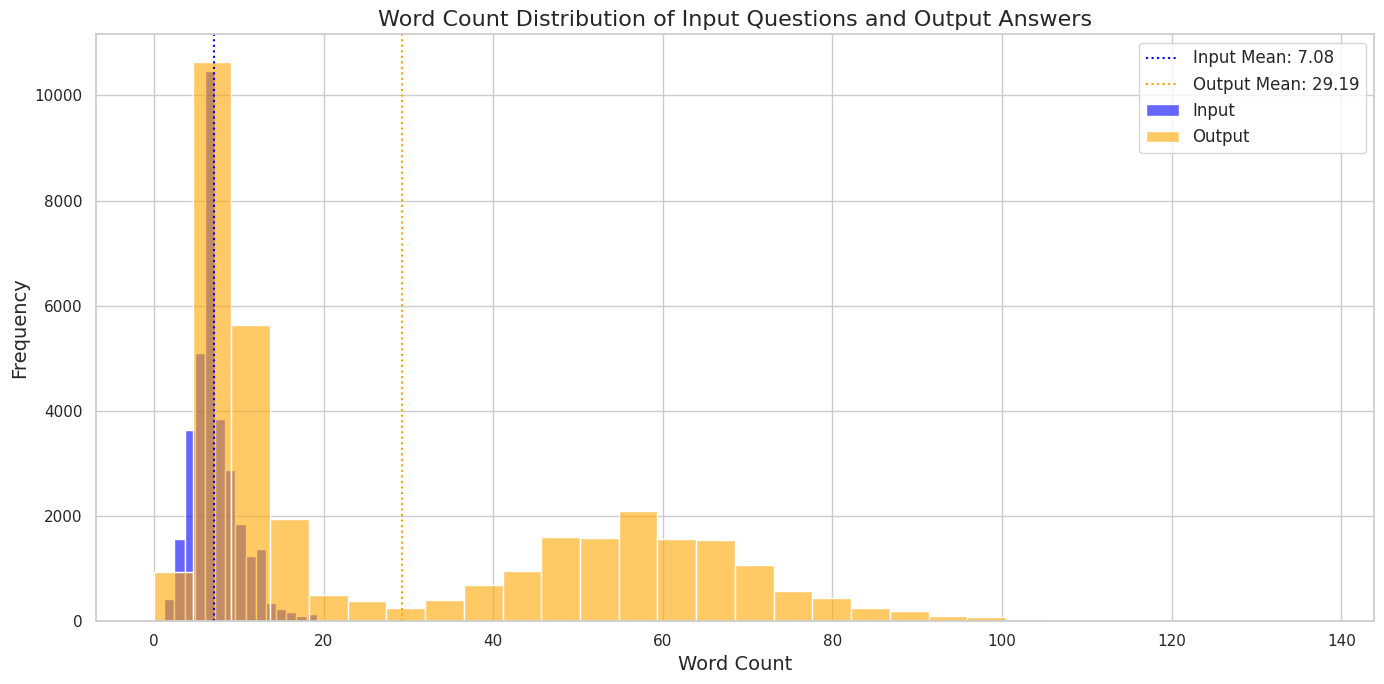

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

# Plot histograms with transparency
sns.histplot(df['input_word_count'], bins=30, kde=False, color='blue', label='Input', alpha=0.6)
sns.histplot(df['output_word_count'], bins=30, kde=False, color='orange', label='Output', alpha=0.6)

# Add vertical lines for means
input_mean = df['input_word_count'].mean()
output_mean = df['output_word_count'].mean()
plt.axvline(input_mean, color='blue', linestyle='dotted', label=f'Input Mean: {input_mean:.2f}')
plt.axvline(output_mean, color='orange', linestyle='dotted', label=f'Output Mean: {output_mean:.2f}')


plt.title('Word Count Distribution of Input Questions and Output Answers', fontsize=16)
plt.xlabel('Word Count', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()

# Show plot
plt.show()

#### Vocabulary Size: number of unique words in each flashcard

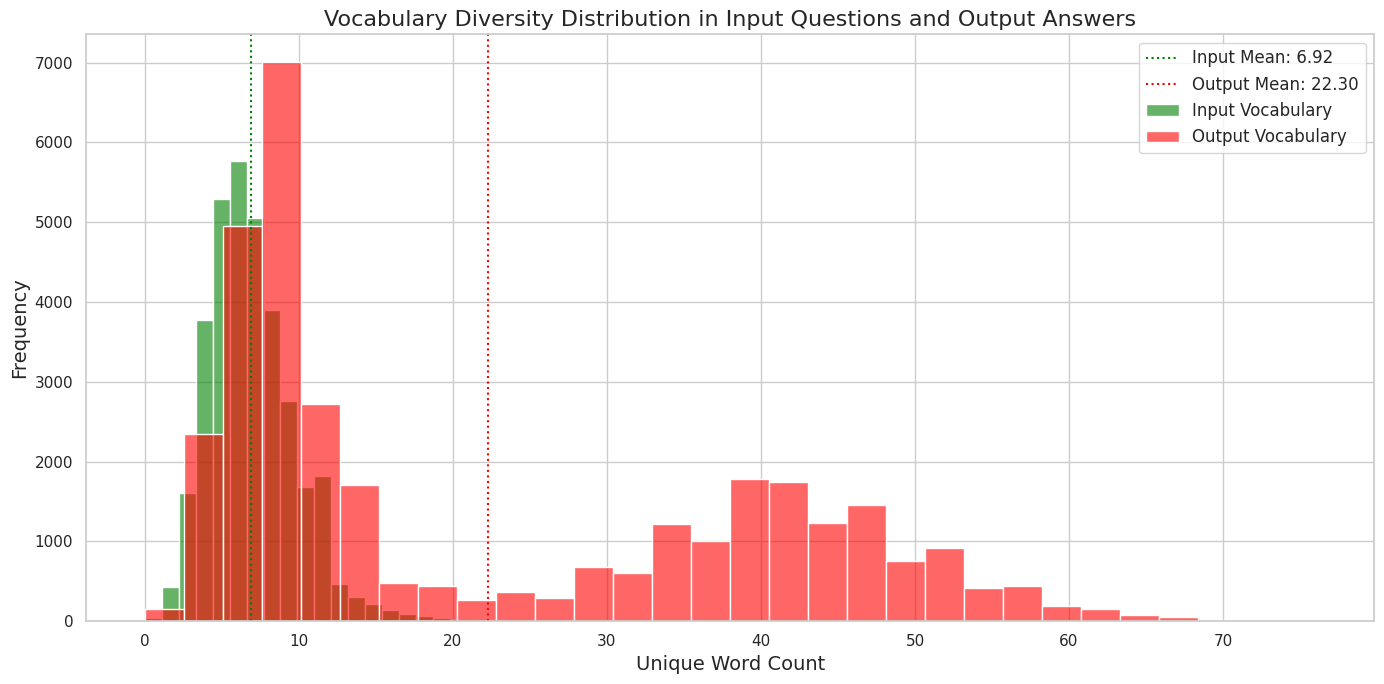

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Create the figure
plt.figure(figsize=(14, 7))

# Plot histograms for unique word counts with KDE
sns.histplot(df['input_unique_words'], bins=30, kde=False, color='green', label='Input Vocabulary', alpha=0.6)
sns.histplot(df['output_unique_words'], bins=30, kde=False, color='red', label='Output Vocabulary', alpha=0.6)

# Add vertical lines for mean unique word counts
input_vocab_mean = df['input_unique_words'].mean()
output_vocab_mean = df['output_unique_words'].mean()
plt.axvline(input_vocab_mean, color='green', linestyle='dotted', label=f'Input Mean: {input_vocab_mean:.2f}')
plt.axvline(output_vocab_mean, color='red', linestyle='dotted', label=f'Output Mean: {output_vocab_mean:.2f}')

plt.title('Unique Word Count Distribution in Input Questions and Output Answers', fontsize=16)
plt.xlabel('Unique Word Count', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

The unique word count for inputs peaks higher at the start, indicating that most input questions are short with limited vocabulary diversity.

Outputs have a wider range of unique word counts compared to inputs, reflecting greater lexical variety in the responses.

A second peak in the output vocabulary distribution can be observed around 40, indicating a subset of outputs with significantly higher vocabulary diversity. This could point to certain types of answers requiring more descriptive language.

Afterwards, we trained a **Word2Vec** model using the questions and answers. Word2Vec is an algorithm that creates embeddings for words based on their context within the text.

We opted to use the **Continuous Bag of Words (CBOW)** method, which predicts a word based on the surrounding context.

 The model was configured with:
- 100 dimensions for word embeddings,
- A context window of 5 words,
- Words appearing fewer than 2 times in the dataset were excluded to reduce noise.

To evaluate the quality of the embeddings, we tested the model by querying similar words to a given term based on cosine similary in the vector space. The model identified words with similar contexts to a specific word.

In [ ]:
all_sentences = df['question_tokens_spacy2'].tolist() + df['answer_tokens_spacy2'].tolist()

In [ ]:
# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=all_sentences,  # Tokenized and lemmatized sentences
    vector_size=100,          # Size of word embeddings
    window=5,                 # Context window size
    min_count=2,              # Minimum frequency of words
    workers=4,                # Number of CPU threads
    sg=0                      # Use CBOW (sg=0) or Skip-Gram (sg=1)
)

# Save the model
word2vec_model.save("word2vec_model_medicine_spacy_lemmatized.bin")

# Vocabulary size
print("Vocabulary size:", len(word2vec_model.wv))

# Test the model with a word
example_word = 'disease'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Vocabulary size: 15788
Most similar words to 'disease':
[('scleroderma', 0.5218364000320435), ('nephropathy', 0.5109300017356873), ('ibd', 0.49455639719963074), ('polyendocrine', 0.4828892648220062), ('sle', 0.47428008913993835), ('glomerulonephritis', 0.4735983610153198), ('alm', 0.4680469334125519), ('gierke', 0.4654265344142914), ('dementia', 0.4590725898742676), ('ophthalmopathy', 0.45828506350517273)]


**Cosine similarity** is a measure of similarity between two vectors (in this case, word embeddings) that considers the angle between them in a high-dimensional space. It ranges from -1 to 1:
- 1 means the vectors are perfectly aligned (very similar words).
- 0 means the vectors are orthogonal (unrelated words).
- -1 means the vectors are in completely opposite directions (highly dissimilar words).


Example 1: most similar words to 'ibd' using Word2Vec

In [ ]:
example_word = 'ibd'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Most similar words to 'ibd':
[('colitis', 0.8177400231361389), ('ulcerative', 0.8093448281288147), ('extraintestinal', 0.8050191402435303), ('gastritis', 0.7896980047225952), ('psoriasis', 0.7835596799850464), ('arthritis', 0.7617736458778381), ('ankylosing', 0.749035656452179), ('crohn', 0.7430086731910706), ('spondylitis', 0.7406577467918396), ('seronegative', 0.7395521998405457)]


Note that both IBD and colitis are intestinal diseases.

Example 2: most similar words to 'heart' using Word2Vec

In [ ]:
example_word = 'heart'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Most similar words to 'heart':
[('cardiac', 0.6858928799629211), ('ventricular', 0.6715620160102844), ('atrial', 0.638944149017334), ('ventricle', 0.6135839819908142), ('mitral', 0.5800213813781738), ('sufficiently', 0.5632789731025696), ('loudness', 0.5501441359519958), ('cardiomyopathy', 0.5497223138809204), ('thrive', 0.5471956133842468), ('chf', 0.5460911393165588)]


Example 3: Finding Words Closely Related to 'disease', 'treatment', and 'patient' Using Word2Vec

In [ ]:
for word in ['disease', 'treatment', 'patient']:
    if word in word2vec_model.wv:
        print(f"Most similar words to '{word}':")
        print(word2vec_model.wv.most_similar(word))

Most similar words to 'disease':
[('scleroderma', 0.5218364000320435), ('nephropathy', 0.5109300017356873), ('ibd', 0.49455639719963074), ('polyendocrine', 0.4828892648220062), ('sle', 0.47428008913993835), ('glomerulonephritis', 0.4735983610153198), ('alm', 0.4680469334125519), ('gierke', 0.4654265344142914), ('dementia', 0.4590725898742676), ('ophthalmopathy', 0.45828506350517273)]
Most similar words to 'treatment':
[('management', 0.6691777110099792), ('combination', 0.5823731422424316), ('treat', 0.5686941742897034), ('intervention', 0.5614147782325745), ('manage', 0.5525709986686707), ('therapy', 0.5323958992958069), ('address', 0.5301515460014343), ('pericardiectomy', 0.5113915801048279), ('adjustment', 0.5018854737281799), ('fosphenytoin', 0.49971699714660645)]
Most similar words to 'patient':
[('individual', 0.6821537613868713), ('people', 0.5878326296806335), ('woman', 0.5263442993164062), ('spousal', 0.5104579329490662), ('child', 0.503369927406311), ('regular', 0.48619407415

#### Word Cloud Analysis of Input and Output Tokens

The word clouds below illustrate the most frequent words from the tokenized and lemmatized input and output fields in the dataset. The size of each word reflects its frequency in the respective dataset field.

In [ ]:
!pip install wordcloud

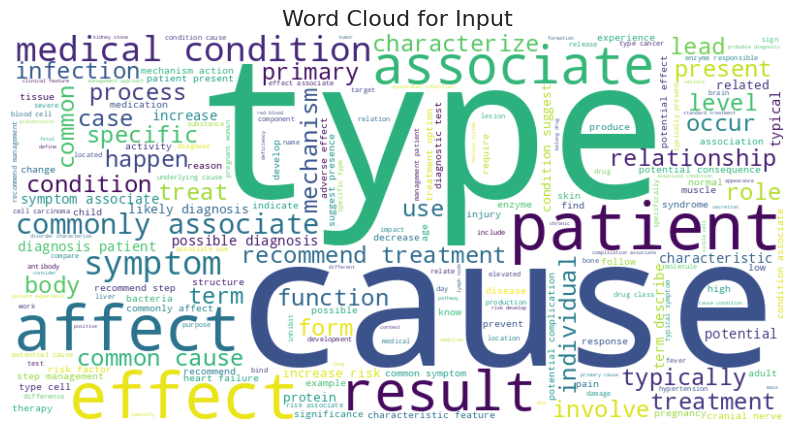

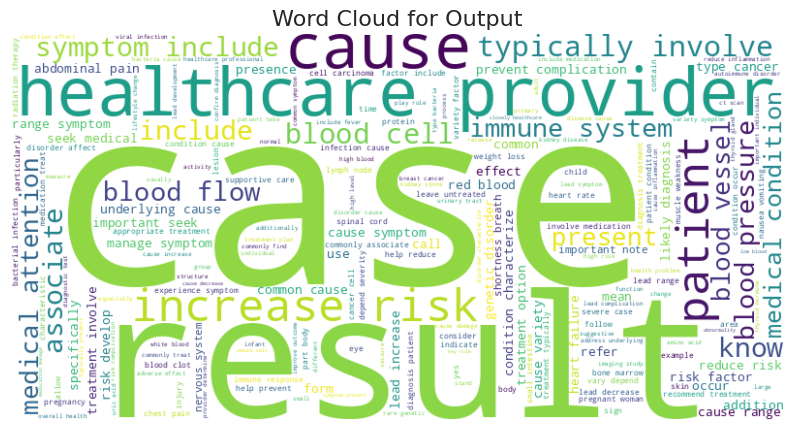

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds
def generate_wordcloud(tokens_series, title):
    # Flatten the list of tokenized words into a single string
    text = " ".join(" ".join(tokens) for tokens in tokens_series)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Word clouds for input and output
generate_wordcloud(df['question_tokens_spacy2'], "Word Cloud for Input")
generate_wordcloud(df['answer_tokens_spacy2'], "Word Cloud for Output")



- **Input Word Cloud:** The most prominent words include "type", "cause", "patient" and "affect." These terms suggest that the input prompts focus on identifying causes, associations, and classifications, which aligns with the nature of questions commonly asked in medical education.

- **Output Word Cloud:** Words like "result", "case" "healthcare provider" and "risk" are prominent. This indicates that outputs are geared towards providing outcomes, explanations, or implications, often expanding on the input prompts.



#### Vocabulary Growth Curve using unique words

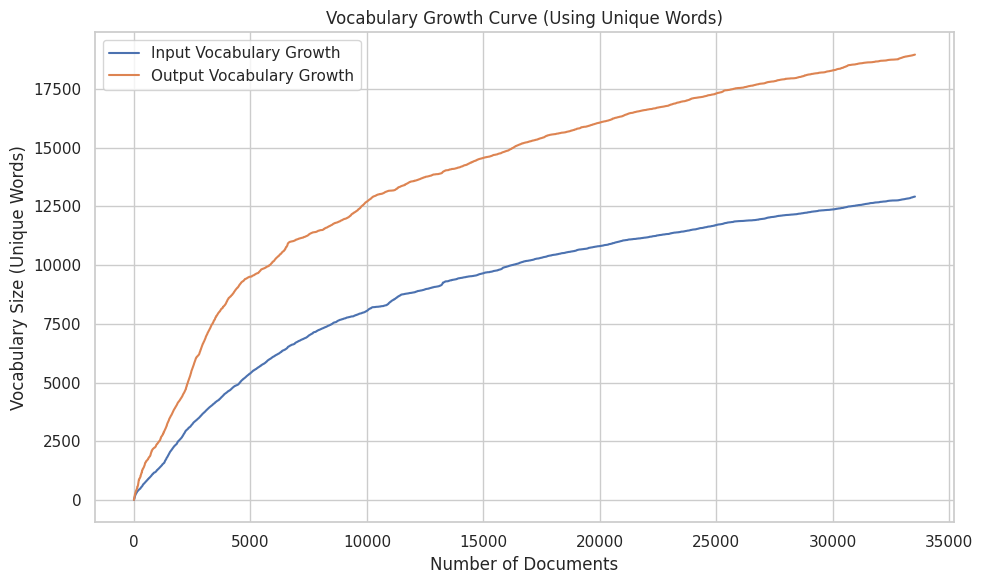

In [ ]:
def compute_vocab_growth_unique_tokens(token_series):
    vocab = set()
    vocab_sizes = []
    for tokens in token_series:
        vocab.update(tokens)  # Add unique tokens from each document
        vocab_sizes.append(len(vocab))  # Track vocabulary size at this point
    return vocab_sizes

# Vocabulary growth for inputs and outputs
input_vocab_growth = compute_vocab_growth_unique_tokens(df['question_tokens_spacy2'])
output_vocab_growth = compute_vocab_growth_unique_tokens(df['answer_tokens_spacy2'])

# Plot vocabulary growth
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(input_vocab_growth) + 1), input_vocab_growth, label='Input Vocabulary Growth')
plt.plot(range(1, len(output_vocab_growth) + 1), output_vocab_growth, label='Output Vocabulary Growth')
plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size (Unique Words)")
plt.title("Vocabulary Growth Curve (Using Unique Words)")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows how the vocabulary size increases as more documents are processed for both input and output.


- Toward the end (around 30,000 documents), the growth of the lines slows down slightly. This indicates that most common words have already been encountered, and adding more documents introduces fewer new unique words.


- The vocabulary in the output is significantly larger than that in the input.

#### Top 20 Most Common Words in Inputs and Outputs


The 20 most common words in the input and ouput are computed.


Top 20 Most Common Words in Inputs (Excluding Stopwords):
[('type', 3543), ('cause', 3474), ('patient', 3012), ('associate', 2734), ('condition', 2168), ('cell', 1891), ('treatment', 1836), ('effect', 1833), ('symptom', 1679), ('recommend', 1512), ('syndrome', 1511), ('disease', 1436), ('commonly', 1393), ('common', 1366), ('potential', 1355), ('affect', 1270), ('present', 1246), ('typically', 1203), ('infection', 1021), ('level', 994)]

Top 20 Most Common Words in Outputs (Excluding Stopwords):
[('cause', 13379), ('treatment', 9305), ('cell', 8991), ('symptom', 8733), ('blood', 8515), ('include', 8166), ('condition', 7750), ('lead', 7055), ('patient', 6838), ('infection', 6063), ('type', 6053), ('important', 5656), ('disease', 5565), ('increase', 5362), ('involve', 5071), ('medication', 4959), ('typically', 4663), ('body', 4354), ('risk', 4233), ('occur', 4093)]


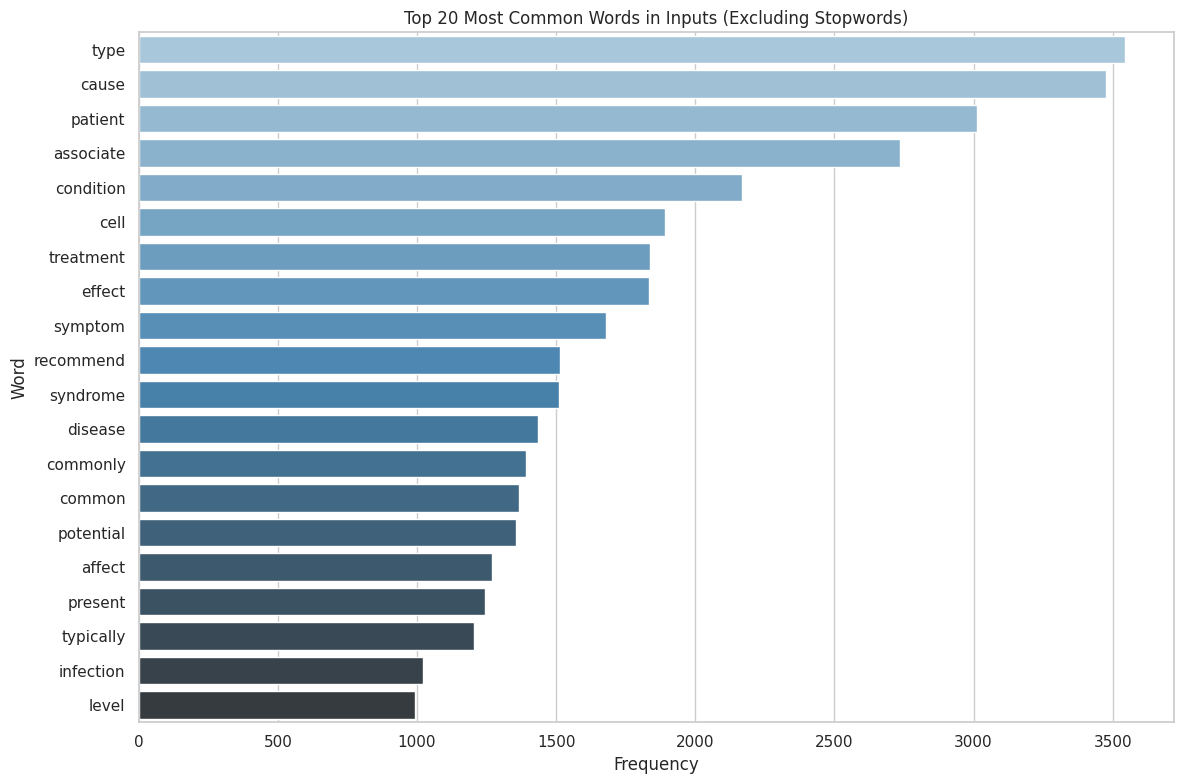

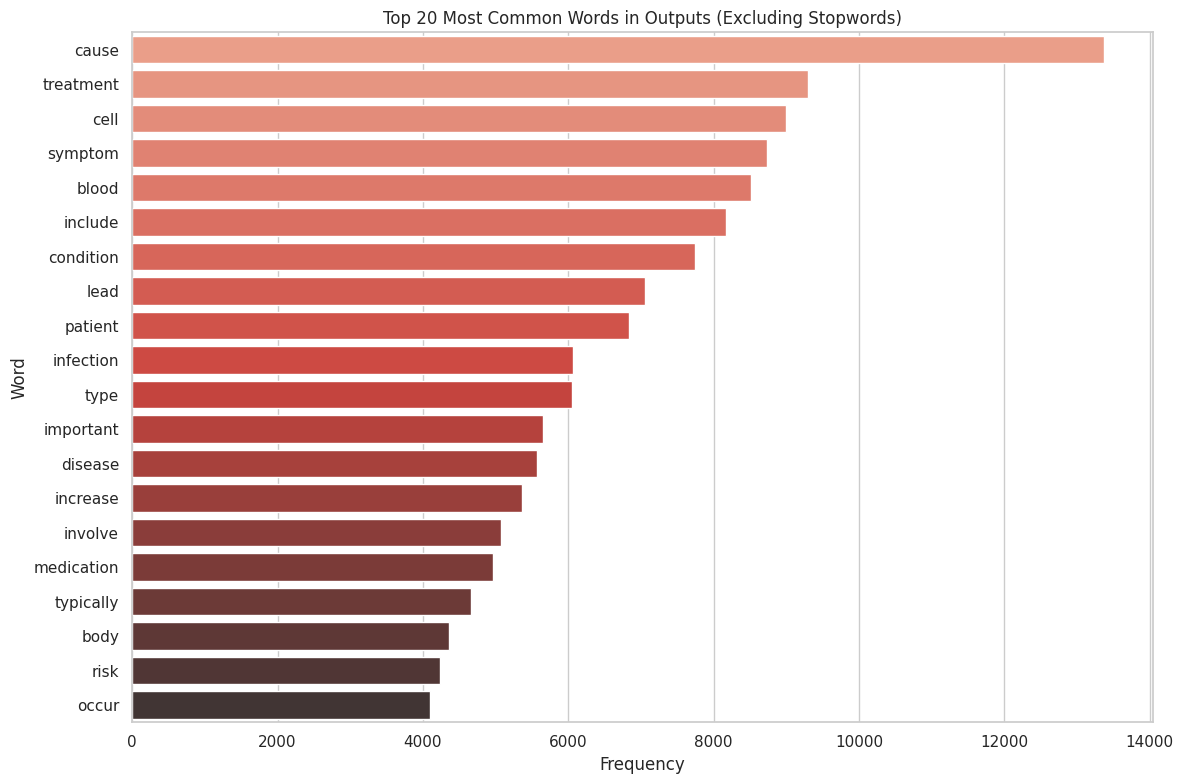

In [ ]:
from collections import Counter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Combine all tokens from inputs and outputs
all_input_tokens = [word for tokens in df['question_tokens_spacy2'] for word in tokens]
all_output_tokens = [word for tokens in df['answer_tokens_spacy2'] for word in tokens]

# Count frequency
input_freq = Counter(all_input_tokens)
output_freq = Counter(all_output_tokens)

# Get top 20
top_input = input_freq.most_common(20)
top_output = output_freq.most_common(20)

print("\nTop 20 Most Common Words in Inputs (Excluding Stopwords):")
print(top_input)

print("\nTop 20 Most Common Words in Outputs (Excluding Stopwords):")
print(top_output)

# Visualization of Top Words

# Inputs
input_top_df2 = pd.DataFrame(top_input, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=input_top_df2, x='Frequency', y='Word', palette='Blues_d')
plt.title('Top 20 Most Common Words in Inputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# Outputs
output_top_df2 = pd.DataFrame(top_output, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=output_top_df2, x='Frequency', y='Word', palette='Reds_d')
plt.title('Top 20 Most Common Words in Outputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


While both inputs and outputs share some common terms (e.g., "cause," "patient," "treatment"), outputs are more descriptive and include more detailed medical terminology, reflecting their role in providing informative answers to the questions in the inputs.


### Vector Embeddings Using openAI

We use OpenAI's text-embedding-3-small model to embed entire questions and answers as vectors.


**In this section:**
  - **Creation of Embeddings:** Use OpenAI's embedding model to generate high-dimensional semantic vectors for each text.
  - **Dimensionality Reduction:** Apply t-SNE to project embeddings into 2D or 3D space for visualization.
  - **Clustering:** Use K-Means to group similar embeddings into clusters and analyze their themes.

In [ ]:
!pip install openai

In [ ]:
!pip install gdown

In [ ]:
from google.colab import userdata
import os
import pandas as pd
import time
from tqdm import tqdm
import numpy as np
from ast import literal_eval
import openai

USE_STORED_EMBEDDINGS = False
if not USE_STORED_EMBEDDINGS:
    openai.api_key = ''
    client = openai

    df4 = pd.DataFrame(columns=['combined', 'ada_embedding'])
    df4['combined'] = df.apply(
        lambda row: f"Question: {row['input']} Answer: {row['output']}", axis=1
    )

    # Verify the DataFrame
    print(df4)
    print(type(df4))

    # This function fetches the embedding for a given text using the specified model.
    def get_embedding(text, model="text-embedding-3-small"):
        text = text.replace("\n", " ")
        return client.embeddings.create(input=[text], model=model).data[0].embedding  # HERE (TODO: ALESSIA)

    # Attempts to fetch the embedding with retries in case of rate limit errors.
    def get_embedding_with_retry(text, model="text-embedding-3-small", max_retries=5, backoff_factor=2):
        for attempt in range(1, max_retries + 1):
            try:
                return get_embedding(text, model)
            except Exception as e:
                print(f"Attempt {attempt} failed with error: {e}")
                if attempt == max_retries:
                    print("Max retries reached. Skipping this text.")
                    return None
                sleep_time = backoff_factor ** attempt
                print(f"Retrying in {sleep_time} seconds...")
                time.sleep(sleep_time)

    embeddings = []

    # Delay between requests (in seconds)
    # To stay under 50 RPS, delay should be at least 0.02 seconds
    DELAY_BETWEEN_REQUESTS = 0.025  # 25 ms

    for text in tqdm(df4['combined'], desc="Generating Embeddings"):
        embedding = get_embedding_with_retry(text, model='text-embedding-3-small')
        embeddings.append(embedding)
        time.sleep(DELAY_BETWEEN_REQUESTS)  # Respect rate limit

    df4['ada_embedding'] = embeddings

    # Save the embeddings
    df4.to_pickle('embedded_flashcards.pkl')
    print("Embeddings generated and saved successfully.")

else:
    # Use gdown to download the file
    !gdown --id 1ioYBymBUr8kBdFDYwI1g8WoJDUXx9pOq -O embedded_flashcards.pkl
    df4 = pd.read_pickle('./embedded_flashcards.pkl')
    display(df4)


                                                combined ada_embedding
0      Question: What is the relationship between ver...           NaN
1      Question: What leads to genitourinary syndrome...           NaN
2      Question: What does low REM sleep latency and ...           NaN
3      Question: What are some possible causes of low...           NaN
4      Question: How does the level of anti-müllerian...           NaN
...                                                  ...           ...
33516  Question: What is Opsoclonus-Myoclonus Ataxia ...           NaN
33517  Question: What is Opsoclonus-Myoclonus Ataxia ...           NaN
33518  Question: Is A part of B in a proportion of A/...           NaN
33519  Question: What is the mnemonic "Microtubules G...           NaN
33520  Question: At what age does bed wetting (enures...           NaN

[33521 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>


Generating Embeddings:   0%|          | 58/33521 [00:29<4:47:58,  1.94it/s]


KeyboardInterrupt: 

**Limits:**
The platform's usage limits are outlined in the official documentation, which is accessible [here](https://platform.openai.com/settings/organization/limits).

**Code and Implementation:**
The implementation details for embedding models are available in OpenAI's official guide [here](https://platform.openai.com/docs/guides/embeddings/embedding-models). I referred to this documentation to understand and adapt the code for this project.

**Embeddings File:**
The file containing embeddings generated using OpenAI's models is publicly available at the following link: [Google Drive - Embeddings File](https://drive.google.com/file/d/1ioYBymBUr8kBdFDYwI1g8WoJDUXx9pOq/view?usp=sharing). Can be downloaded automatically with the following code:






#### 2-dimensional t-SNE

In this section we combined K-Means clustering with t-SNE visualization to analyze our dataset effectively.

First, we applied K-Means directly to the original high-dimensional feature space. This allowed us to cluster the data while preserving all the feature information, ensuring that the resulting clusters were accurate and meaningful.

Next, we used t-SNE to visualize the data. Since t-SNE projects the high-dimensional data into a 2D space, it provided an intuitive way to explore the clusters created by K-Means. While t-SNE does not influence the clustering results, its visualization allowed us to identify patterns, validate the clusters and better understand their structure.

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import numpy as np
from ast import literal_eval

# Convert the 'ada_embedding' to an array
matrix = np.array(df4['ada_embedding'].tolist())

# Create a t-SNE model and transform the data
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='random', learning_rate=200)
vis_dims = tsne.fit_transform(matrix)
vis_dims.shape
print(tsne)

TSNE(init='random', learning_rate=200, perplexity=40, random_state=42)


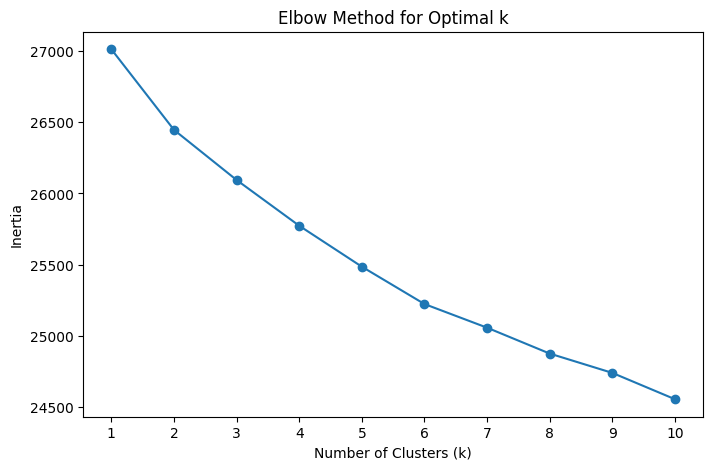

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine inertia for different values of k
inertia = []
k_values = range(1, 11)  # Test k from 1 to 10
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(matrix)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

**Choice of k:**  
The value of k = 5 was selected for the k-means clustering algorithm based on the elbow method. This method involves plotting the sum of squared distances (inertia) for different values of k and identifying the point where the rate of decrease sharply changes, forming an "elbow" in the graph.

At k = 5, the marginal gain in clustering performance diminished, making it a suitable choice for our analysis.


The 2D t-SNE visualization provides a flattened view of the clusters created using K-Means, making it easier to identify patterns and relationships in the data. Clusters like 1 and 2 show overlap, suggesting shared themes, while cluster 3 stands out as the most distinct, reflecting its unique focus.

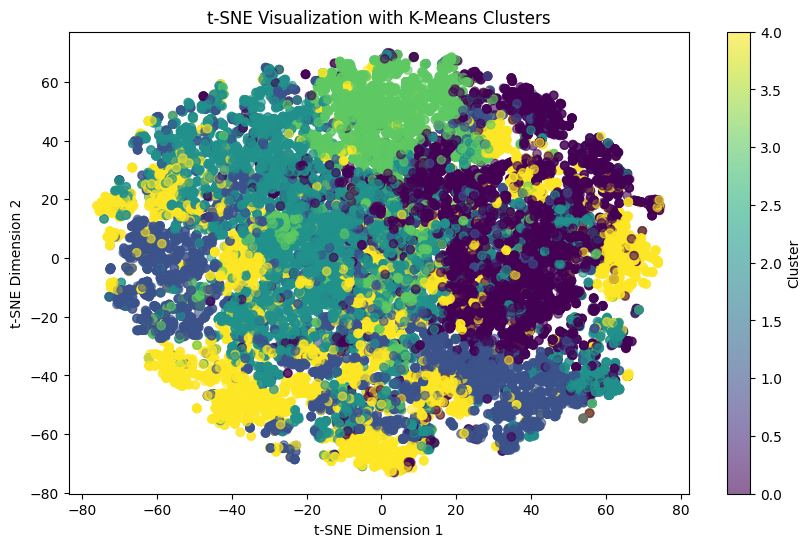

In [ ]:
from sklearn.cluster import KMeans

# Perform k-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df4['cluster'] = kmeans.fit_predict(matrix)

# Add t-SNE results to the DataFrame
df4['tsne_x'] = vis_dims[:, 0]
df4['tsne_y'] = vis_dims[:, 1]

# Visualize clusters
plt.figure(figsize=(10, 6))
plt.scatter(df4['tsne_x'], df4['tsne_y'], c=df4['cluster'], cmap='viridis', alpha=0.6)
plt.title("t-SNE Visualization with K-Means Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
# Group the data by cluster and inspect its content
for cluster in df4['cluster'].unique():
    print(f"Cluster {cluster}:")
    print(df4[df4['cluster'] == cluster]['combined'].head(10))  # View top 10 items in the cluster
    print("\n")

Cluster 4:
0     Question: What is the relationship between ver...
4     Question: How does the level of anti-müllerian...
31    Question: How does high estrogen, such as duri...
34    Question: What is the relationship between hig...
38    Question: What are the two substances that reg...
39    Question: What are the regulators that control...
40    Question: What is the name of the enzyme that ...
41    Question: What is the product of the conversio...
51    Question: What is the result of β-thalassemia ...
52    Question: What is the impact of β-thalassemia ...
Name: combined, dtype: object


Cluster 2:
1     Question: What leads to genitourinary syndrome...
2     Question: What does low REM sleep latency and ...
9     Question: What condition is associated with lo...
10    Question: What is the relationship between low...
11    Question: What condition is suggested by low C...
13    Question: What is the relationship between low...
14    Question: What is the term used to describe 

#### **Cluster Description**
The cluster description has been derived by analyzing the flashcards within the cluster, focusing on their shared themes, key terms, and overall context to identify the shared topics that define the cluster.

##### **Cluster 0: Clinical Diagnosis and Symptoms**
This cluster focuses on recognizing and interpreting clinical signs, symptoms, and diagnostic indicators across different medical fields, including:
- **Ear, Nose, and Throat (ENT):** Signs of ear infections (e.g., acute otitis media).
- **Cardiology:** Heart issues like ejection fraction, murmurs (e.g., HOCM), and mitral stenosis.
- **Pulmonology:** Breathing tests (e.g., FEV1 changes in asthma).
- **Obstetrics/Gynecology:** How oxytocin affects fetal heart rates.
- **Gastroenterology:** Symptoms of indigestion (dyspepsia).
- **Neonatology:** Prenatal screening markers like AFP levels.

---

##### **Cluster 1: Medications – β-Blockers and β-Lactam Antibiotics**
This cluster is all about β-blockers and β-lactam antibiotics, covering:
- How they work.
- Their effects and uses.
- When not to use them (contraindications).

---

##### **Cluster 2: Hormones, Metabolism, and Diagnostics**
This cluster includes questions about hormonal and metabolic disorders, focusing on:
- **Endocrinology:** Hormonal issues like secondary hyperparathyroidism or calcium-related imbalances.
- **Nephrology:** Kidney problems, such as dietary calcium's effect on stones and pseudohyponatremia.
- **Hematology:** Blood disorders like polycythemia vera.
- **Rheumatology:** Joint diseases caused by crystals (e.g., gout, pseudogout).

---

##### **Cluster 3: Hormones, Cancer and Fertility**
This cluster combines hormone-related conditions with cancer and reproductive health, including:
- **Endocrinology:** Calcium issues caused by PTH and insulin-related conditions (e.g., insulinoma).
- **Oncology:** Tumor markers like high hCG (e.g., choriocarcinoma) or neuroblastoma signs in babies.
- **Reproductive Health:** Genetic tests for hormonal issues (e.g., high FSH with delayed puberty).

---

##### **Cluster 4: Body Chemistry and Genetic Disorders**
This cluster explores the biochemical and genetic basis of conditions, such as:
- **Biochemistry:** Pathways like heme synthesis and how enzymes are regulated.
- **Genetics/Hematology:** Mutations in β-thalassemia affecting hemoglobin.
- **Endocrine Physiology:** Hormone interactions (e.g., estrogen and thyroid proteins) and mineral regulation (e.g., magnesium’s role in PTH and calcium).



In [ ]:
# Add cluster results to df4
df4['cluster'] = kmeans.labels_

# Group items by clusters and save to clustered_results
clustered_results = df4.groupby('cluster')['combined'].apply(list).reset_index()

clustered_results.columns = ['Cluster', 'Items']

The following word clouds provide a visual representation of the most frequent terms for each of the five clusters identified in the dataset.

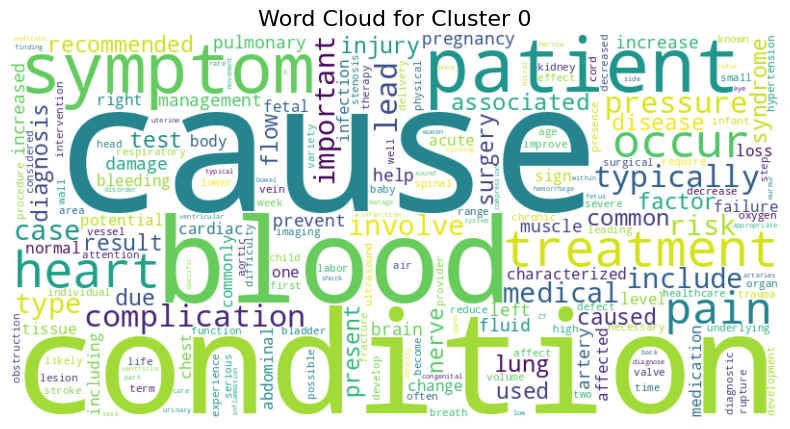

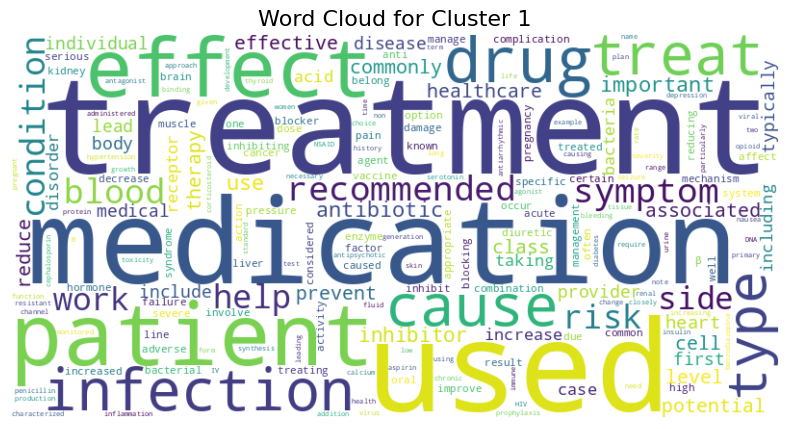

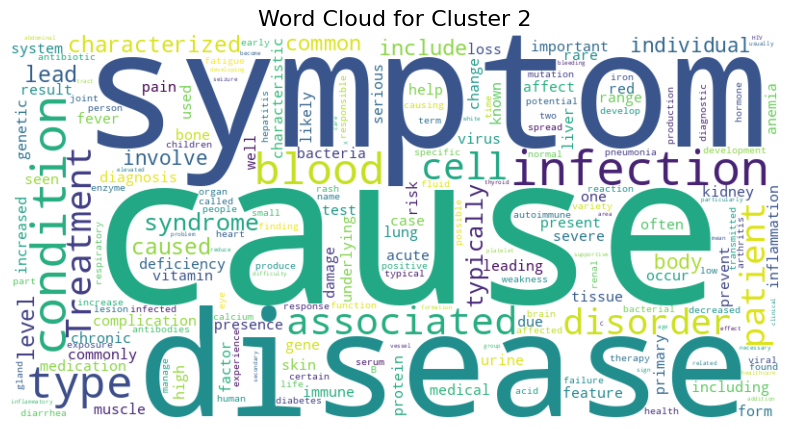

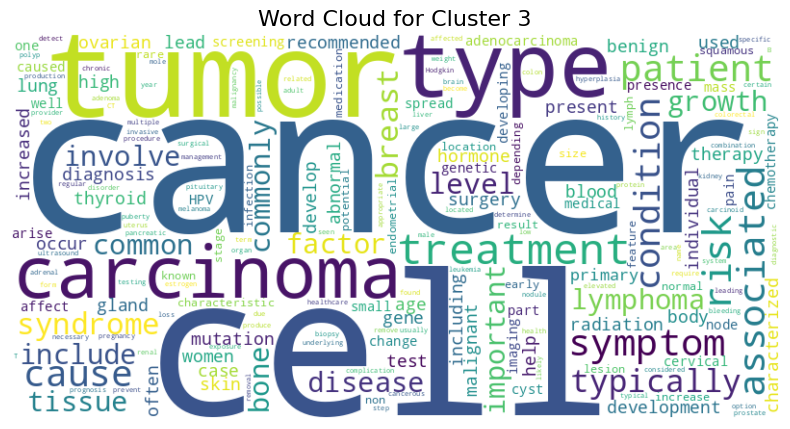

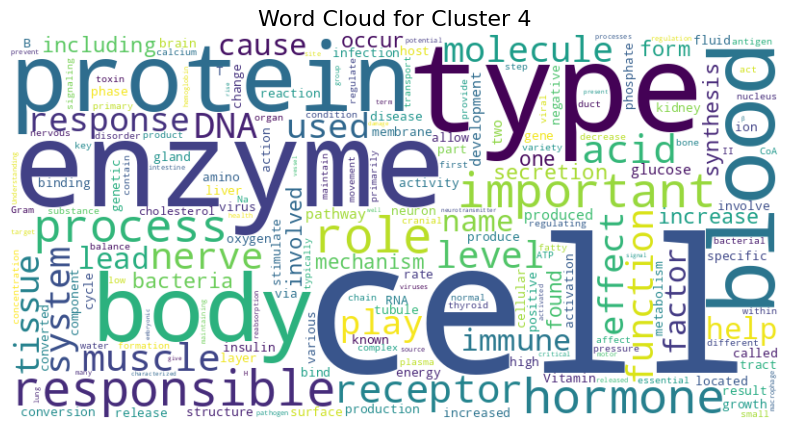

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Define additional stopwords
additional_stopwords = {"question", "answer","may"}

# Combine additional stopwords with the default stopwords
stopwords = STOPWORDS.union(additional_stopwords)

# Word clouds for each cluster
for _, row in clustered_results.iterrows():
    cluster = row['Cluster']
    items = " ".join(row['Items'])

    # Generate a word cloud with custom stopwords
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,  # Exclude specified stopwords
        collocations=False  # Optional: Avoid combining words
    ).generate(items)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Cluster {cluster}", fontsize=16)
    plt.show()



The word cloud for **Cluster 0** highlights terms like "symptom," "condition," "heart," and "pain," reflecting its focus on diagnosing and interpreting clinical signs across various medical fields, such as cardiology and pulmonology.

For **Cluster 1**, key terms like "treatment," "medication," "drug," and "effect" emphasize its focus on pharmacology, particularly the mechanisms, effects, and uses of β-blockers and β-lactam antibiotics.

The word cloud for **Cluster 2** highlights terms like "symptom," "cause," "disease," and "blood," reflecting its focus on hormonal, metabolic, and diagnostic disorders such as calcium imbalances, kidney issues, and blood disorders.

For **Cluster 3**, key terms like "tumor," "cancer," "carcinoma," and "hormone" emphasize its focus on oncology, hormone-related conditions, and reproductive health, including topics like choriocarcinoma and fertility issues.

The word cloud for **Cluster 4** highlights terms like "enzyme," "protein," "cell," and "process," emphasizing its focus on biochemical pathways and genetic mechanisms. This aligns with its theme of exploring body chemistry, such as hormone interactions and conditions like β-thalassemia.

**Limitations:**  
Word clouds are not very effective for understanding the meanings of the clusters, as they focus only on word frequency and don’t provide enough context or relationships between the words.



#### 3-dimensional t-SNE

The two-dimensional t-SNE visualization, while helpful for an initial exploration of the clusters, does not provide enough detail to fully capture the structure of the data. Therefore, we decided to use a three-dimensional t-SNE representation to gain a more informative understanding of the clusters.



To free memory and proceed with the rest of the code that does not relay on the previous stored variables

In [ ]:
import gc
del tsne
gc.collect()

In [ ]:
from sklearn.manifold import TSNE

# Create a t-SNE model with 3 components
tsne = TSNE(
    n_components=3,
    perplexity=40,
    random_state=42,
    init='random',
    learning_rate=200
)

# Transform the data
vis_dims = tsne.fit_transform(matrix)
print("t-SNE Shape:", vis_dims.shape)

t-SNE Shape: (33521, 3)


In [ ]:
df4[['tsne_x', 'tsne_y', 'tsne_z']] = pd.DataFrame(vis_dims, index=df4.index)

In [ ]:
from sklearn.cluster import KMeans

# Perform k-means clustering on the original embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
df4['cluster'] = kmeans.fit_predict(matrix)

We visualize the clusters in the projected 3D space.

In [ ]:
import plotly.express as px

# 3D scatter plot
fig = px.scatter_3d(
    df4,
    x='tsne_x',  # Dimension 1
    y='tsne_y',  # Dimension 2
    z='tsne_z',  # Dimension 3
    color='cluster',  # Coloring by cluster
    title="t-SNE 3D Visualization with K-Means Clusters",
    opacity=0.7
)

# Interactive plot
fig.show()

The 3D t-SNE visualization offers a comprehensive view on the clusters in a medical context, allowing us to observe patterns and relationships that align with the thematic focus of each cluster. Clusters that appear closer in the t-SNE space, such as clusters 1 and 2 or clusters 1 and 4, likely reflect shared or overlapping themes in their medical focus.

For example, **Cluster 1: Medications - β-Blockers and β-Lactam Antibiotics** and **Cluster 2: Hormones, Metabolism, and Diagnostics** share potential overlap in diagnostic approaches and medication considerations for related conditions, such as kidney or metabolic disorders. Similarly, **Cluster 1** and **Cluster 4: Body Chemistry and Genetic Disorders** may intersect due to biochemical mechanisms underlying medication effects and genetic factors influencing treatment responses.

Conversely, clusters that are more distinct in the t-SNE plot, such as **Cluster 0: Clinical Diagnosis and Symptoms** and **Cluster 3: Hormones, Cancer, and Fertility**, indicate fundamentally different themes. **Cluster 0** focuses on the clinical presentation and diagnostic signs across various specialties, while **Cluster 3** centers on hormone-related conditions, reproductive health, and oncology, representing a unique thematic group in the dataset.


In [ ]:
from scipy.spatial.distance import cdist
import pandas as pd

# Assuming df_clusters contains the t-SNE coordinates and cluster labels
# Compute centroids of each cluster in the 3D space
centroids = df4.groupby('cluster')[['tsne_x', 'tsne_y', 'tsne_z']].mean()

# Compute pairwise distances between centroids
distances = cdist(centroids, centroids, metric='euclidean')

# Convert distances to a DataFrame for better readability
distance_df = pd.DataFrame(
    distances,
    index=centroids.index,
    columns=centroids.index
)

# Display the distances
print(distance_df)

cluster          0          1          2          3          4
cluster                                                       
0         0.000000  21.700460  18.870153  24.936184  22.412540
1        21.700460   0.000000  11.865944  30.410768  12.716346
2        18.870153  11.865944   0.000000  20.151005  13.408840
3        24.936184  30.410768  20.151005   0.000000  22.999001
4        22.412540  12.716346  13.408840  22.999001   0.000000


The distance matrix shows the Euclidean distances between the centroids of the clusters. Smaller distances indicate closer clusters in the t-SNE space, suggesting thematic or feature similarities, while larger distances indicate greater separation and distinctiveness.

Smaller distances:
- Clusters 1 and 2 have the smallest distance (11.86), suggesting close thematic overlap. As the plot shows, they are positioned near each other, likely reflecting shared topics like metabolism and medication.
- Clusters 1 and 4 are also relatively close (12.71). The plot supports this, showing their proximity, which may relate to common biochemical or genetic factors.

Larger distances:
- Clusters 1 and 3 are the most distant (30.41), highlighting their distinct themes. As seen in the plot, they occupy separate areas, reflecting unrelated topics like medications in Cluster 1 and hormone-related cancers in Cluster 3.
- Clusters 0 and 3 have a significant separation (24.93). The plot clearly shows this, with Cluster 0 focusing on clinical diagnosis and Cluster 3 on hormones and fertility.

The plot visually supports the relationships described by the distance matrix, showing both thematic overlaps and distinctions.

Let's analyze the terms that appear in different clusters.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Extract items from clusters as text data
cluster_items = df4.groupby('cluster')['combined'].apply(' '.join)

# Use CountVectorizer to find common terms across clusters
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(cluster_items)

# Create a DataFrame of terms and their frequencies per cluster
terms = vectorizer.get_feature_names_out()
term_frequencies = pd.DataFrame(X.toarray(), index=cluster_items.index, columns=terms)

# Find clusters with overlapping terms
overlap_matrix = term_frequencies.T.corr()

# Display the thematic overlap matrix
print(overlap_matrix)

In the medical field, many terms are used across different topics or conditions.

Clusters 0 and 2 have a high overlap (0.923), suggesting similar thematic content.
Clusters 3 and 4 also exhibit strong similarity (0.885).




In [ ]:
# Extract terms and their frequencies for Clusters 0 and 2
cluster_0_terms = term_frequencies.loc[0]
cluster_2_terms = term_frequencies.loc[2]

# Combine terms into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Cluster 0 Frequency': cluster_0_terms,
    'Cluster 2 Frequency': cluster_2_terms
}).sort_values(by=['Cluster 0 Frequency', 'Cluster 2 Frequency'], ascending=False)

# Exclude specific terms such as "question" and "answer"
excluded_terms = ['question', 'answer']
comparison_df = comparison_df[~comparison_df.index.isin(excluded_terms)]

# Add a column to highlight shared terms (where both clusters have non-zero frequency)
comparison_df['Shared Term'] = (comparison_df['Cluster 0 Frequency'] > 0) & (comparison_df['Cluster 2 Frequency'] > 0)

# Display the DataFrame
print(comparison_df)



### Indexing and Searching

**WHOOSH (Indexing and Searching)**

Whoosh is a pure Python search engine library that allows you to index and search text data efficiently. It uses the TF-IDF (Term Frequency-Inverse Document Frequency) algorithm by default to rank search results based on their relevance.

Whoosh handles tokenization internally based on the schema you define. Whoosh will tokenize, analyze, and process the text according to the field definitions in the schema.


The algorithm TF-IDF has two main components:

a. Term Frequency (TF):
This measures how frequently a term appears in a document. The more frequent a word occurs, the more important it is to that specific document.

b. Inverse Document Frequency (IDF):
This measures how unique or rare a term is across the entire corpus. A term that appears in many documents (e.g., "the", "is") gets a lower weight, while rarer terms get a higher weight.

In [ ]:
!pip install pandas whoosh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 9.2 MB/s eta 0:00:00


In [ ]:
flashcards_df=df
# Check if 'id' column exists; if not, create one
if 'id' not in flashcards_df.columns:
    flashcards_df.insert(0, 'id', range(1, len(flashcards_df) + 1))

We can search for the most similar flashcards given a user-defined input.

In [ ]:
from whoosh import index
from whoosh.fields import Schema, TEXT, ID
from whoosh.analysis import StemmingAnalyzer
from whoosh.qparser import MultifieldParser
import os
import shutil


if 'id' not in flashcards_df.columns:
    flashcards_df.insert(0, 'id', range(1, len(flashcards_df) + 1))

# Check validate data
required_columns = {'id', 'input', 'output'}
if not required_columns.issubset(flashcards_df.columns):
    missing = required_columns - set(flashcards_df.columns)
    raise ValueError(f"The following required columns are missing from the dataset: {missing}")

flashcards_df = flashcards_df.dropna(subset=['id', 'input', 'output'])
flashcards = flashcards_df.to_dict('records')

# Whoosh schema
schema = Schema(
    id=ID(stored=True, unique=True),
    input=TEXT(stored=True, analyzer=StemmingAnalyzer()),
    output=TEXT(stored=True, analyzer=StemmingAnalyzer())
)

index_dir = "flashcard_index"
if os.path.exists(index_dir):
    shutil.rmtree(index_dir)
    print(f"Deleted existing index directory '{index_dir}' due to schema mismatch.")

os.mkdir(index_dir)
ix = index.create_in(index_dir, schema)
print(f"Created new index with the updated schema in '{index_dir}'.")

# Index the flashcards
with ix.writer() as writer:
    for card in flashcards:
        try:
            writer.update_document(
                id=str(card["id"]),
                input=card["input"],
                output=card["output"]
            )
        except KeyError as e:
            print(f"Missing key {e} in flashcard: {card}")
    print("Indexing completed.")

def search_flashcards(query_str, limit=10):
    with ix.searcher() as searcher:
        parser = MultifieldParser(["input", "output"], schema=ix.schema)
        try:
            query = parser.parse(query_str)
        except Exception as e:
            print(f"Error parsing query: {e}")
            return
        results = searcher.search(query, limit=limit)
        if not results:
            print("No matching flashcards found.")
            return
        for hit in results:
            print(f"ID: {hit['id']}")
            print(f"Question: {hit['input']}")
            print(f"Answer: {hit['output']}")
            print("-" * 40)


print("Flashcard Search")
print("Type 'exit' to quit.")
while True:
    user_query = input("Enter search query: ")
    if user_query.lower() == 'exit':
        print("Exiting search.")
        break
    search_flashcards(user_query)

Created new index with the updated schema in 'flashcard_index'.
Indexing completed.
Flashcard Search
Type 'exit' to quit.
Enter search query: cancer
ID: 31461
Question: What are the most common types of cancers, excluding skin cancer?
Answer: Aside from skin cancer, the highest incidence cancers are breast/prostate cancer, lung cancer, and colorectal cancer.
----------------------------------------
ID: 30721
Question: Among all types of cancer, which cancer has the highest incidence?
Answer: Breast/prostate cancer is the 1st most common cancer by incidence.
----------------------------------------
ID: 22949
Question: In terms of cancer-related deaths, where does lung cancer rank among other types of cancer?
Answer: Lung cancer is the most common cancer by mortality, accounting for more deaths than any other type of cancer. This is due in part to the fact that lung cancer is often not detected until it has reached an advanced stage, when it is more difficult to treat. Additionally, lung

---

## Model Training and Evaluation

First, the necessary packages are installed.

In [ ]:
!pip install -q -U transformers bitsandbytes accelerate xformers datasets peft trl
!pip install -q loralib

A Huggingface token needs to be provided since the Llama models are in a gated repository. Furthermore, the device is set to cuda to use the GPU.

In [ ]:
device = "cuda"

from google.colab import userdata

HUGGINGFACE_TOKEN = userdata.get("HUGGINGFACE_TOKEN")

In [ ]:
from huggingface_hub import login

login(token=HUGGINGFACE_TOKEN)

### Finetuning
We are finetuning the Llama 3.2 Instruct 1B and the Llama 3.2 Instruct 3B models.

#### Llama 3.2 Instruct 1B
The [Llama 3.2 1B instruction tuned model](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct) is used. We use 8 bit quantization for faster inference and training. Note that the quantization only works on the GPU.

Since it is infeasible to train all of the over one billion parameters of the model, we use [LoRA](https://arxiv.org/pdf/2106.09685) for instruction tuning. This means we only need to train a small number of additional low-rank matrices, while keeping the original model's weights frozen.

In [ ]:
from transformers import LlamaTokenizer, LlamaForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# Load the model and tokenizer
llama_1B_model_name = "meta-llama/Llama-3.2-1B-Instruct"
llama_1B_tokenizer = AutoTokenizer.from_pretrained(llama_1B_model_name)

# If the tokenizer does not have a pad_token, set it manually
if llama_1B_tokenizer.pad_token is None:
    llama_1B_tokenizer.pad_token = "[PAD]"
    llama_1B_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

llama_1B_quantization_config = BitsAndBytesConfig(load_in_8bit=True)

llama_1B_model = LlamaForCausalLM.from_pretrained(llama_1B_model_name, device_map="auto", quantization_config=llama_1B_quantization_config)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
from peft import prepare_model_for_kbit_training, get_peft_model

# Configure LoRA
llama_1B_lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

llama_1B_prepared_model = prepare_model_for_kbit_training(llama_1B_model)
llama_1B_qlora_model = get_peft_model(llama_1B_prepared_model, llama_1B_lora_config)

To verify that the model was correctly loaded, the $\texttt{chat}$ function was implemented, which allows the user to interact with the model through a chat interface.

In [ ]:
def chat(model, tokenizer):
  while True:
      # Interactive input from the user
      question = input("Enter your question (or type 'exit' to quit): ")
      if question.lower() == 'exit':
          print("Exiting the assistant.")
          break

      # Prepare the input text
      input_text = (
          f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
          "You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n"
          f"{question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>"
      )

      # Tokenize the input text and specify pad_token_id and attention_mask
      inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True).to(device)

      # Ensure the attention_mask and pad_token_id are set
      attention_mask = inputs.get("attention_mask", None)
      pad_token_id = tokenizer.pad_token_id  # Use the tokenizer's default pad_token_id

      # Perform inference (generate predictions)
      outputs = model.generate(
          inputs["input_ids"], attention_mask=attention_mask, max_length=512, num_return_sequences=1, pad_token_id=pad_token_id
      )

      # Decode the generated text
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

      # Extract only the assistant's response by removing the prompt
      # Note that the special tokens are skipped in the text
      if question in generated_text:
          assistant_response = generated_text.split(question+"assistant", 1)[-1].strip()
      else:
          assistant_response = generated_text.strip()

      print("\n")
      print(assistant_response)
      print("--------------------------------------------------------------------------")

Now, we can ask the model some questions. For instance:
- What types of bacterial infections is penicillin commonly used to treat?
- Which organ is primarily responsible for maintaining acid-base balance in the body?
- Which molecule is the primary source of energy for cellular metabolism?
- Which type of cell is responsible for producing antibodies?

In [ ]:
chat(llama_1B_qlora_model, llama_1B_tokenizer)

Enter your question (or type 'exit' to quit): What types of bacterial infections is penicillin commonly used to treat?


/usr/local/lib/python3.10/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")




Penicillin is a broad-spectrum antibiotic that is commonly used to treat a wide range of bacterial infections. It is effective against many types of bacteria, including:

1. **Streptococcal infections**: Penicillin is effective against streptococcal infections, such as strep throat, skin infections, and skin infections caused by Group A beta-hemolytic streptococci (GABHS).
2. **Staphylococcal infections**: Penicillin is effective against Staphylococcus aureus, a common cause of skin and soft tissue infections, as well as respiratory tract infections.
3. **Meningitis**: Penicillin is used to treat meningitis, an inflammation of the lining of the brain and spinal cord.
4. **Endocarditis**: Penicillin is used to treat endocarditis, an infection of the heart valves.
5. **Septicemia**: Penicillin is used to treat septicemia, a life-threatening condition where bacteria enter the bloodstream.
6. **Urinary tract infections (UTIs)**: Penicillin is used to treat UTIs, including uncomplicated a

For instruction tuning, we use the medical flashcards dataset from the [medAlpaca](https://arxiv.org/pdf/2304.08247) paper. This dataset consists of Anki medical flashcards created by medical students, covering the entire medical curriculum. The authors employed OpenAI's GPT-3.5-turbo to convert each flashcard into a question-answer pair. To maintain comparability with medAlpaca, and given that the number of problematic training examples is minimal, we used the full dataset instead of the cleaned version for fine-tuning.

We create a process function so that the training data follows the Llama 3.2 Instruct [prompt format](https://github.com/meta-llama/llama-models/blob/main/models/llama3_2/text_prompt_format.md).

In [ ]:
from datasets import load_dataset

flashcards_dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards", split="train")

def preprocess(example):
    txt = [
      f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\nAnswer this question truthfully.<|eot_id|>\n<|start_header_id|>user<|end_header_id|>\n\n{inp}<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>\n{outp}"
      for instruction, inp, outp in zip(example["instruction"], example["input"], example["output"])
    ]
    return txt

README.md:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

(…)l_meadow_wikidoc_medical_flashcards.json:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33955 [00:00<?, ? examples/s]

We can fine-tune the Llama 3.2 1B model, but since the fine-tuning process takes several hours, we provide the weights of the fine-tuned model in the $\texttt{llama-1B_flashcards}$ directory. If the $\texttt{USE_SAVED_MODEL}$ flag is set to $\texttt{true}$, the code will load the pre-trained model from the saved weights instead of performing the fine-tuning.


In [ ]:
from transformers import TrainingArguments, Trainer, AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM

import os

USE_SAVED_MODEL = True
MODEL_DIR = "./llama-1B_flashcards"

training_args = SFTConfig(
    output_dir="./train-1B/llama-medical-flashcards",
    eval_strategy="no",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    bf16=True,
    push_to_hub=False,
    report_to="none",
    max_seq_length=1024,
)

if USE_SAVED_MODEL:
  llama_1B_flashcards_model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, device_map="auto", quantization_config=llama_1B_quantization_config)
  llama_1B_flashcards_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
else:
  trainer = SFTTrainer(
    llama_1B_qlora_model,
    args=training_args,
    train_dataset=flashcards_dataset,
    formatting_func=preprocess,
  )
  trainer.train()

  llama_1B_qlora_model.save_pretrained(MODEL_DIR)
  llama_1B_tokenizer.save_pretrained(MODEL_DIR)

We can also chat with the fine-tuned model to verify that everything is working as intented.

In [ ]:
chat(llama_1B_flashcards_model, llama_1B_flashcards_tokenizer)

Enter your question (or type 'exit' to quit): What types of bacterial infections is penicillin commonly used to treat?


Penicillin is commonly used to treat bacterial infections caused by susceptible strains of bacteria, such as Streptococcus pneumoniae, Haemophilus influenzae, and Staphylococcus aureus. These types of infections include:

* Pneumonia, which is an infection of the lungs
* Skin infections, such as cellulitis and abscesses
* Urinary tract infections, such as pyelonephritis and cystitis
* Meningitis, which is an infection of the lining around the brain and spinal cord
* Bloodstream infections, such as sepsis and bacteremia

However, it's worth noting that penicillin is not effective against all types of bacterial infections, and resistance to penicillin can occur in some cases. As a result, other antibiotics may be needed to treat infections caused by penicillin-resistant bacteria.
--------------------------------------------------------------------------
Enter your ques

#### Llama 3.2 Instruct 3B
Next, we use the [Llama 3.2 3B instruction tuned model](https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct). This model is from the same family but has more parameters. Again, 8 bit quantization is used.

In [ ]:
from transformers import LlamaTokenizer, LlamaForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# Load the model and tokenizer
llama_3B_model_name = "meta-llama/Llama-3.2-3B-Instruct"
llama_3B_tokenizer = AutoTokenizer.from_pretrained(llama_3B_model_name)

# If the tokenizer does not have a pad_token, set it manually
if llama_3B_tokenizer.pad_token is None:
    llama_3B_tokenizer.pad_token = "[PAD]"
    llama_3B_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

llama_3B_quantization_config = BitsAndBytesConfig(load_in_8bit=True)

llama_3B_model = LlamaForCausalLM.from_pretrained(llama_3B_model_name, device_map="auto", quantization_config=llama_3B_quantization_config)

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

As with the Llama 3.2 Instruct 1B model, LoRA is used.

In [ ]:
from peft import prepare_model_for_kbit_training, get_peft_model

# Configure LoRA
llama_3B_lora_config = LoraConfig(
    r=32,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

llama_3B_prepared_model = prepare_model_for_kbit_training(llama_3B_model)
llama_3B_qlora_model = get_peft_model(llama_3B_prepared_model, llama_3B_lora_config)

Again, we can chat with the model to make sure the model is correctly loaded.

In [ ]:
chat(llama_3B_model, llama_3B_tokenizer)

Enter your question (or type 'exit' to quit): What types of bacterial infections is penicillin commonly used to treat?


/usr/local/lib/python3.10/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")




Penicillin is a type of antibiotic that is commonly used to treat a variety of bacterial infections. Here are some examples of bacterial infections that penicillin is commonly used to treat:

1. **Strep throat**: Penicillin is often prescribed to treat strep throat, a bacterial infection caused by Group A Streptococcus.
2. **Pneumonia**: Penicillin is used to treat bacterial pneumonia, which is a lung infection caused by bacteria such as Streptococcus pneumoniae.
3. **Skin infections**: Penicillin is often used to treat skin infections such as cellulitis, erysipelas, and impetigo.
4. **Urinary tract infections (UTIs)**: Penicillin is used to treat UTIs, which are bacterial infections of the bladder, kidneys, or urethra.
5. **Meningitis**: Penicillin is used to treat bacterial meningitis, a serious infection of the membranes surrounding the brain and spinal cord.
6. **Tonsillitis**: Penicillin is used to treat bacterial tonsillitis, which is an infection of the tonsils.
7. **Otitis me

We can fine-tune the Llama 3.2 3B model, but since the fine-tuning process takes several hours, we provide the weights of the fine-tuned model in the $\texttt{llama-3B_flashcards}$ directory. If the $\texttt{USE_SAVED_MODEL}$ flag is set to $\texttt{true}$, the code will load the pre-trained model from the saved weights instead of performing the fine-tuning.


In [ ]:
from transformers import TrainingArguments, Trainer, AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM

import os

USE_SAVED_MODEL = True
MODEL_DIR = "./llama-3B_flashcards"

os.environ["WANDB_PROJECT"] = "advtop-nlp-proj"

training_args = SFTConfig(
    output_dir="./train-3B/llama-medical-flashcards",
    eval_strategy="no",
    learning_rate=2e-5,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    bf16=True,
    push_to_hub=False,
    report_to="none",
    max_seq_length=1024,
)

if USE_SAVED_MODEL:
  llama_3B_flashcards_model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, device_map="auto", quantization_config=llama_3B_quantization_config)
  llama_3B_flashcards_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
else:
  trainer = SFTTrainer(
    llama_3B_qlora_model,
    args=training_args,
    train_dataset=flashcards_dataset,
    formatting_func=preprocess,
  )
  trainer.train()

  llama_3B_qlora_model.save_pretrained(MODEL_DIR)
  llama_3B_tokenizer.save_pretrained(MODEL_DIR)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

To make sure the fine-tuned model is correctly loaded, we can chat with the model.

In [ ]:
chat(llama_3B_flashcards_model, llama_3B_flashcards_tokenizer)

Enter your question (or type 'exit' to quit): What types of bacterial infections is penicillin commonly used to treat?


Penicillin is commonly used to treat a variety of bacterial infections, including:

1. Strep throat: Penicillin is often prescribed to treat strep throat, a bacterial infection that causes inflammation of the throat.
2. Pneumonia: Penicillin is used to treat pneumonia caused by Streptococcus pneumoniae, a type of bacteria that can cause the infection.
3. Meningitis: Penicillin is used to treat meningitis, a bacterial infection that inflames the membranes surrounding the brain and spinal cord.
4. Skin infections: Penicillin is used to treat skin infections such as cellulitis, abscesses, and impetigo.
5. Urinary tract infections (UTIs): Penicillin is used to treat UTIs caused by certain types of bacteria, such as Escherichia coli (E. coli).
6. Gonorrhea: Penicillin is used to treat gonorrhea, a bacterial infection that affects the reproductive organs.
7. Syphilis: Peni

### Evaluation using the USMLE dataset
The models performances are assessed based on their zero-shot capabilities across the United States Medical Licensing Examination (USMLE) Step 1, Step 2, and Step 3 self-assessment datasets. The USMLE is the required examination for obtaining medical licensure in the United States. It is a single choice exam. [Wikipedia](https://en.wikipedia.org/wiki/United_States_Medical_Licensing_Examination) provides a description of the different steps:
- Step 1: "Application of scientific principles basic to the practice of medicine"
- Step 2: "Application of medical knowledge, skills, and understanding of clinical science essential for supervised patient care"
- Step 3: "Application of medical knowledge and understanding of biomedical and clinical science essential for the unsupervised practice of medicine"

Depending on the question, there are three to nine options to choose from. One should note that the questions are almost impossible to answer for somebody without a background in medicine.

The USMLE dataset is from the [medAlpaca](https://arxiv.org/pdf/2304.08247) paper. The evaluation code is adapted from the medAlpaca code. This allows us to compare our results with theirs. The data set consists of six files. For each step there are two files: one containing the questions and the answer options and a file containing the solutions. These files are in the $\texttt{eval}$ folder.

#### Investigating the USMLE dataset
Before the models are evaluated, the USMLE dataset is investigated.

In [ ]:
import os
import json

questions_saved = []

for step_idx in range(1, 4):
    with open(f"./eval/step{step_idx}.json") as fp:
        questions = json.load(fp)

        with open(f"./eval/step{step_idx}_solutions.json") as sol_fp:
          solutions = json.load(sol_fp)

        for question in questions:
            if question.get("image") or question.get("image_url"):
              continue

            question_number = str(question["no"])
            solution = None
            if question_number in solutions:
                solution = solutions[question_number]

            num_options = len(question["options"])
            questions_saved.append({
                "question": question["question"],
                "step": step_idx,
                "numberAnswerOptions": num_options,
                "solution": solution
            })

We investigate the distribution of the number of answer options. Most questions have five answer options.

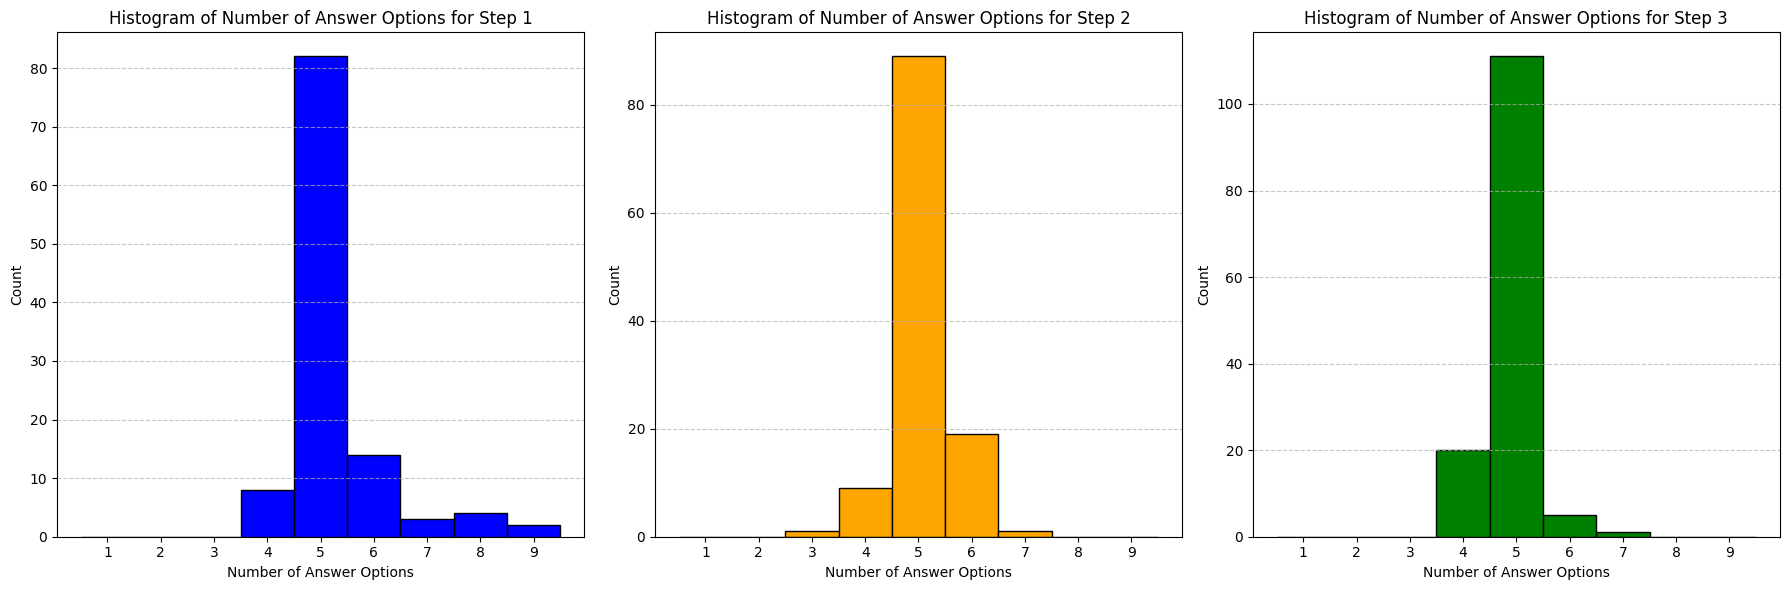

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

answer_options_by_step = defaultdict(list)

for question in questions_saved:
    step = question["step"]
    num_options = question["numberAnswerOptions"]
    answer_options_by_step[step].append(num_options)

colors = ["blue", "orange", "green"]
labels = [f"Step {i}" for i in range(1, 4)]

# Define the bin edges to center bins on x-axis labels
bin_edges = np.arange(0.5, 10.5, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each histogram on its respective subplot
for step_idx, color, label, ax in zip(range(1, 4), colors, labels, axes):
    ax.hist(answer_options_by_step[step_idx], bins=bin_edges,
            alpha=1.0, edgecolor="black", color=color)

    ax.set_xticks(np.arange(1, 10))
    ax.set_xticklabels(np.arange(1, 10))

    ax.set_title(f"Histogram of Number of Answer Options for {label}")
    ax.set_xlabel("Number of Answer Options")
    ax.set_ylabel("Count")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Next, the distribution of the solution is investigated. The distribution for the answer options A to E is (very) roughly uniform, as expected. Since many questions do not have more than five answers options, options F and G are not frequently the solution.

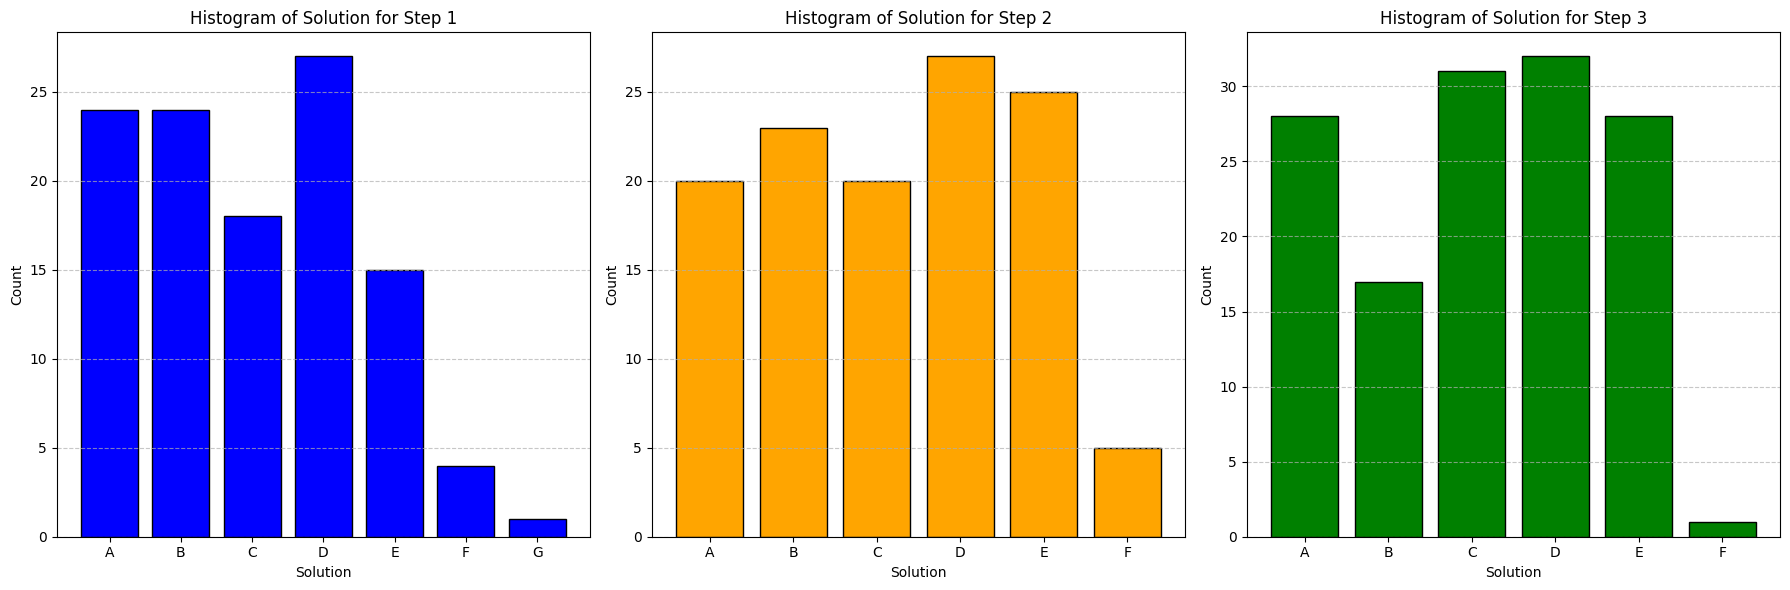

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

solutions_by_step = defaultdict(list)

for question in questions_saved:
    step = question["step"]
    solution = question["solution"]
    if solution is None:
        continue
    solutions_by_step[step].append(solution)

colors = ["blue", "orange", "green"]
labels = [f"Step {i}" for i in range(1, 4)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot each histogram on its respective subplot
for step_idx, color, label, ax in zip(range(1, 4), colors, labels, axes):
    # Count occurrences of each unique solution (A, B, C, etc.)
    unique_solutions, counts = np.unique(solutions_by_step[step_idx], return_counts=True)

    ax.bar(unique_solutions, counts, color=color, edgecolor="black")

    ax.set_title(f"Histogram of Solution for {label}")
    ax.set_xlabel("Solution")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Before we proceed to the evaluation, we experiment with the questions in the evaluation dataset. Using the [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) model, the questions are embedded in a 768 dimensional vector space.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

sentences = [q["question"] for q in questions_saved]
steps = [q["step"] for q in questions_saved]

embeddings = model.encode(sentences)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

We can find the most similar questions to a given question by calculating pairwise cosine distances. You can try to find the most similar questions to the question with id 110, for instance.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

similarity_matrix = cosine_similarity(embeddings)

def find_k_most_similar(index, k):
    similarity_scores = similarity_matrix[index]

    # Exclude the question itself by setting its similarity to -1
    similarity_scores[index] = -1

    # Get the indices of the top k most similar questions
    top_k_indices = similarity_scores.argsort()[-k:][::-1]

    return [(similarity_scores[i], sentences[i], steps[i]) for i in top_k_indices]


def interactive_find_similar(index, k):
    most_similar_questions = find_k_most_similar(index, k)

    clear_output(wait=True)

    display(index_input, k_input, display_button)

    print(f"\nSelected Question:")
    print(f"Step: {steps[index]}, Question: {sentences[index]}")

    print("\nMost similar questions:")
    print(f"{'Step':<10}{'Similarity':<12}{'Question':<50}")
    print("-" * 80)
    for score, question, step in most_similar_questions:
        cleaned_question = question.strip().replace("\n", " ")
        print(f"{step:<10}{score:<12.4f}{cleaned_question:<50}")


# Create interactive widgets
index_input = widgets.IntSlider(value=0, min=0, max=len(sentences)-1, description="Question:")
k_input = widgets.IntSlider(value=5, min=1, max=10, description="k:")

# Button to display results
# The 200px is necessary to see the entire button text
display_button = widgets.Button(description="Show similar questions", layout=widgets.Layout(width="200px"))

def on_button_click(b):
    index = index_input.value
    k = k_input.value
    interactive_find_similar(index, k)

display_button.on_click(on_button_click)

# Display the widgets
display(index_input, k_input, display_button)

IntSlider(value=0, description='Question:', max=369)

IntSlider(value=5, description='k:', max=10, min=1)

Button(description='Show similar questions', layout=Layout(width='200px'), style=ButtonStyle())

Furthermore, we can find the most similar question in the evaluation dataset to a user-provided question. For instance, try the question "Does the patient have a broken arm?"

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.feature_extraction.text import TfidfVectorizer


def find_k_most_similar_to_user_question(user_question, k):
    user_question_embedding = model.encode([user_question])
    similarity_scores = cosine_similarity(user_question_embedding, embeddings).flatten()

    # Get the indices of the top k most similar questions
    # Note that the [::-1] reverses the order
    top_k_indices = similarity_scores.argsort()[-k:][::-1]

    return [(similarity_scores[i], sentences[i], steps[i]) for i in top_k_indices]

def interactive_find_similar_to_user_question(user_question, k):
    most_similar_questions = find_k_most_similar_to_user_question(user_question, k)

    clear_output(wait=True)

    display(question_input, k_input, display_button)

    print(f"\nYour question:")
    print(f"{user_question}")

    print("\nMost similar questions:")
    print(f"{'Step':<10}{'Similarity':<12}{'Question':<50}")
    print("-" * 80)
    for score, question, step in most_similar_questions:
        cleaned_question = question.strip().replace("\n", " ")
        print(f"{step:<10}{score:<12.4f}{cleaned_question:<50}")


# Create interactive widgets
question_input = widgets.Text(
    value="",
    placeholder="Type a question...",
    description="Question:",
    layout=widgets.Layout(width="70%")
)

k_input = widgets.IntSlider(value=5, min=1, max=10, description="k:")

# Button to display results
display_button = widgets.Button(description="Show similar questions", layout=widgets.Layout(width="200px"))

def on_button_click(b):
    user_question = question_input.value
    k = k_input.value
    interactive_find_similar_to_user_question(user_question, k)

display_button.on_click(on_button_click)

# Display the widgets
display(question_input, k_input, display_button)

Text(value='', description='Question:', layout=Layout(width='70%'), placeholder='Type a question...')

IntSlider(value=5, description='k:', max=10, min=1)

Button(description='Show similar questions', layout=Layout(width='200px'), style=ButtonStyle())

Next, we visualize the embeddings by projecting them into three-dimensional space using Principal Component Analysis (PCA).

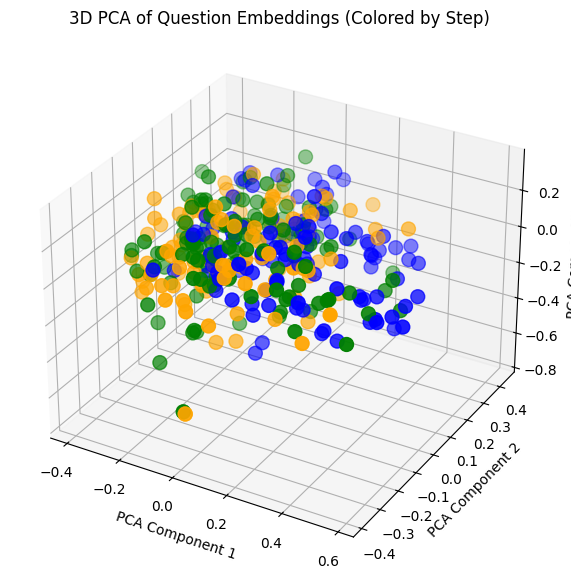

In [ ]:
pca = PCA(n_components=3)
pca_embeddings = pca.fit_transform(embeddings)

# Plot the embeddings in 3D and color them according to the step
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = ["blue", "orange", "green"]
step_colors = [colors[step-1] for step in steps]  # Color according to step (1, 2, or 3)

ax.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], pca_embeddings[:, 2],
           c=step_colors, marker="o", s=100)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D PCA of Question Embeddings (Colored by Step)")

plt.show()

We can not observe a clear clustering of the questions into the three steps. Thus, we cluster the original embeddings using K-Means. However, K-Means does not tell us, which cluster corresponds to which step (or even that the clusters correspond to steps but lets ignore that). This problem is an instance of the well-known [assignment problem](https://en.wikipedia.org/wiki/Assignment_problem) that can be solved using the $\texttt{scipy.optimize.
linear_sum_assignment}$ function.

However, the [adjusted rand index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html), which is a value between -0.5 and 1.0 is 0.05 for the given clustering. A value close to 0 means that the labelling from the clustering is random. An ARI value of 1.0 means perfect match.

The [Normalized Mutual Information (NMI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) is a number between 0 (no mutual information) and 1 (perfect correlation). The NMI score in our case is 0.06.

Both the ARI and NMI score indicate that the clustering is not good, which is confirmed by the confusion matrix. Thus it seems to be non-trivial to cluster the questions by the step. Maybe an embedding model that is adapted to the medicine domain would provide better results.

Adjusted Rand Index (ARI): 0.05
Normalized Mutual Information (NMI): 0.06


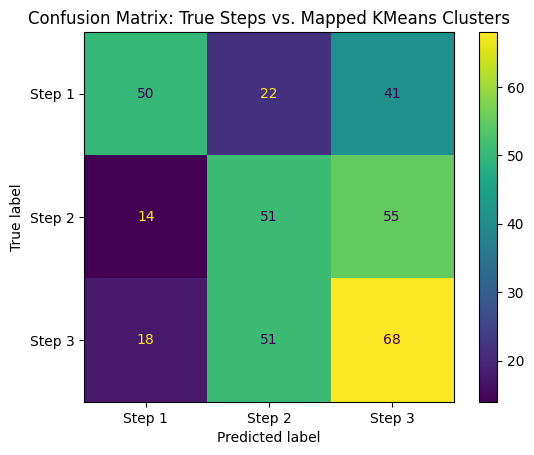

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(embeddings)

true_labels = [step - 1 for step in steps]

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, kmeans_labels)

# Find the best cluster to step mapping
row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Negative because we want to maximize agreement
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Map the predicted labels to the true labels
mapped_labels = [mapping[label] for label in kmeans_labels]

# Calculate performance metrics
ari = adjusted_rand_score(true_labels, mapped_labels)
nmi = normalized_mutual_info_score(true_labels, mapped_labels)

print(f"Adjusted Rand Index (ARI): {ari:.2f}")
print(f"Normalized Mutual Information (NMI): {nmi:.2f}")

# Plot the confusion matrix with the mapped labels
mapped_conf_matrix = confusion_matrix(true_labels, mapped_labels)
ConfusionMatrixDisplay(mapped_conf_matrix, display_labels=["Step 1", "Step 2", "Step 3"]).plot()
plt.title("Confusion Matrix: True Steps vs. Mapped KMeans Clusters")
plt.show()

#### Evaluation
Now, we start with the actual evaluation of the models on the USMLE dataset.

A Llama prompt consists of the instruction, question, and assistant message. The assistant message is optional and can be used to force the model to answer in a certain way. For the evaluation, the instruction for the model is *Answer this multiple choice question with a single capital letter. No justification required.* followed by the question that includes the answer options from the json. Lastly, we add *The Answer to the question is:* to the prompt to incentivice the model to just add a single capital letter to choose the answer.

If a model's output did not conform to the required format, it was prompted up to five times to generate the response correctly. If the model still failed to produce the desired format, the last generated response was retained.

Below, several functions required for the evaluation procedure are prepared.

In [ ]:
from transformers import LogitsProcessor

# The code was adapted from https://github.com/kbressem/medAlpaca/blob/main/eval/eval_usmle.py
def format_question(d):
    question = d["question"]
    options = d["options"]
    for k, v in options.items():
        question += f"\n{k}: {v}"
    return question

def strip_special_chars(input_str):
    "Remove special characters from string start/end"
    if not input_str:
        return input_str

    start_index = 0
    end_index = len(input_str) - 1

    while start_index < len(input_str) and input_str[start_index] not in string.ascii_letters + string.digits:
        start_index += 1

    while end_index >= 0 and input_str[end_index] not in string.ascii_letters + string.digits:
        end_index -= 1

    if start_index <= end_index:
        return input_str[start_index:end_index + 1]
    else:
        return ""

def starts_with_capital_letter(input_str):
    """
    The answers should start like 'A: ' or 'A. ' or 'A '
    """
    if not isinstance(input_str, str):
      return False

    # We use a different regex since we also want to match if there is nothing after the capital letter
    # pattern = r"^[A-Z](:|\.|)( .+|$)"
    pattern = r"^[A-Z]"
    return bool(re.match(pattern, input_str))

def extract_option(response):
    # The model often provides additional characters than just the option (e.g. reason)
    pattern = r"^[A-Z]"
    match = re.search(pattern, response)

    return match.group(0) if match else None

def add_solutions_to_json(output_json_path, question_json_path, solution_json_path):
    with open(solution_json_path) as sol_fp:
        solutions = json.load(sol_fp)

    with open(question_json_path) as fp:
        questions = json.load(fp)

    questions_included = []

    for index, question in enumerate(questions):
        # We only consider questions without an image
        if question.get("image") or question.get("image_url"):
          continue
        solution_key = str(index + 1)
        if solution_key in solutions:
            question["solution"] = solutions[solution_key]
            questions_included.append(question)
        else:
            question["solution"] = None


    with open(output_json_path, "w") as out_fp:
        json.dump(questions_included, out_fp)

In [ ]:
# The code was adapted from https://github.com/kbressem/medAlpaca/blob/main/eval/eval_usmle.py

import re
import json
import string
from transformers import pipeline, LogitsProcessorList
from tqdm.autonotebook import tqdm

def llama3_2_input_formatter(question):
  return f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nAnswer this multiple choice question with a single capital letter. No justification required.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nThe Answer to the question is:"

def generate_evaluation_json(model, tokenizer, model_name, input_formatter, use_forced_options = False, ntries = 5):
  pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, return_full_text=False)
  for step_idx in range(1,4):
    question_json = f"./eval/step{step_idx}.json"
    solution_json = f"./eval/step{step_idx}_solutions.json"
    output_json = f"./eval/step{step_idx}_output_{model_name}.json"

    add_solutions_to_json(output_json, question_json, solution_json)

    with open(output_json) as fp:
        questions = json.load(fp)

    pbar = tqdm(questions)
    pbar.set_description_str(f"Evaluating USMLE Step {step_idx}")

    answers = []

    for i, question in enumerate(pbar):
        for j in range(ntries):
            formatted_question = format_question(question)
            input_text = input_formatter(formatted_question)

            response = pipe(input_text, max_new_tokens=10, num_return_sequences=1, pad_token_id=tokenizer.pad_token_id)[0]["generated_text"]

            response = strip_special_chars(response)

            if starts_with_capital_letter(response):
                pbar.set_postfix_str(f"")
                break
            else:
                pbar.set_postfix_str(f"Output not satisfactoy, retrying {j+1}/{ntries}")

        question["modelAnswer"] = extract_option(response)
        answers.append(question)

        with open(output_json, "w+") as fp:
            json.dump(answers, fp)

In [ ]:
def evaluate_step(output_json_path):
  number_correct = 0
  with open(output_json_path) as fp:
      step = json.load(fp)
      for question in step:
        if question["modelAnswer"] == question["solution"]:
          number_correct += 1
  return number_correct / len(step)

def print_accuracy_per_step(model_name):
  step1_output_json = f"./eval/step{1}_output_{model_name}.json"
  step2_output_json = f"./eval/step{2}_output_{model_name}.json"
  step3_output_json = f"./eval/step{3}_output_{model_name}.json"

  acc_step1 = evaluate_step(step1_output_json)
  acc_step2 = evaluate_step(step2_output_json)
  acc_step3 = evaluate_step(step3_output_json)

  print(f"{model_name:} Step 1 accuracy {acc_step1}")
  print(f"{model_name:} Step 2 accuracy {acc_step2}")
  print(f"{model_name:} Step 3 accuracy {acc_step3}")

Using the code above, the models are evaluated by calculating their accuracy, defined as the ratio of correct answers provided by the model to the total number of questions.

First the Llama-3.2-1B-Instruct model is evaluated.

In [ ]:
llama_1B_model_name = "Llama-3.2-1B-Instruct"  # Can not use real model name because of "/" in name
generate_evaluation_json(llama_1B_model, llama_1B_tokenizer, llama_1B_model_name, llama3_2_input_formatter)
print_accuracy_per_step(llama_1B_model_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-1B-Instruct Step 1 accuracy 0.23893805309734514
Llama-3.2-1B-Instruct Step 2 accuracy 0.4666666666666667
Llama-3.2-1B-Instruct Step 3 accuracy 0.3722627737226277


Next, the Llama-3.2-1B-Instruct model fine-tuned on the medical flashcards dataset is evaluated.

In [ ]:
llama_1B_flashcards_name = llama_1B_model_name + "-Flashcards"
generate_evaluation_json(llama_1B_flashcards_model, llama_1B_flashcards_tokenizer, llama_1B_flashcards_name, llama3_2_input_formatter)
print_accuracy_per_step(llama_1B_flashcards_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-1B-Instruct-Flashcards Step 1 accuracy 0.30973451327433627
Llama-3.2-1B-Instruct-Flashcards Step 2 accuracy 0.375
Llama-3.2-1B-Instruct-Flashcards Step 3 accuracy 0.4233576642335766


Let's also evaluate the Llama-3.2-3B-Instruct.

In [ ]:
llama_3B_model_name = "Llama-3.2-3B-Instruct"  # Can not use real model name because of "/" in name
generate_evaluation_json(llama_3B_model, llama_3B_tokenizer, llama_3B_model_name, llama3_2_input_formatter)
print_accuracy_per_step(llama_3B_model_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-3B-Instruct Step 1 accuracy 0.5398230088495575
Llama-3.2-3B-Instruct Step 2 accuracy 0.7833333333333333
Llama-3.2-3B-Instruct Step 3 accuracy 0.7883211678832117


Lastly, the Llama-3.2-3B-Instruct model fine-tuned on the medical flashcards dataset is evaluated.

In [ ]:
llama_3B_flashcards_name = llama_3B_model_name + "-Flashcards"
generate_evaluation_json(llama_3B_flashcards_model, llama_3B_flashcards_tokenizer, llama_3B_flashcards_name, llama3_2_input_formatter)
print_accuracy_per_step(llama_3B_flashcards_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Llama-3.2-3B-Instruct-Flashcards Step 1 accuracy 0.4778761061946903
Llama-3.2-3B-Instruct-Flashcards Step 2 accuracy 0.775
Llama-3.2-3B-Instruct-Flashcards Step 3 accuracy 0.6934306569343066


We can compare the performance to the results in the medAlpaca paper. The below table shows the performance of different models as reported in the medAlpaca paper.

In [ ]:
import pandas as pd

# The data is taken from the table in the medAlpaca paper
df = pd.DataFrame([
    {"Model": "LLaMA 7b [15]", "Step1": 0.198, "Step2": 0.202, "Step3": 0.203},
    {"Model": "Alpaca 7b naive [11]", "Step1": 0.275, "Step2": 0.266, "Step3": 0.293},
    {"Model": "Alpaca 7b LoRA", "Step1": 0.220, "Step2": 0.138, "Step3": 0.252},
    {"Model": "MedAlpaca 7b", "Step1": 0.297, "Step2": 0.312, "Step3": 0.398},
    {"Model": "MedAlpaca 7b LoRA", "Step1": 0.231, "Step2": 0.202, "Step3": 0.179},
    {"Model": "MedAlpaca 7b LoRA 8bit", "Step1": 0.231, "Step2": 0.241, "Step3": 0.211},
    {"Model": "ChatDoctor (7b) [10]", "Step1": 0.187, "Step2": 0.185, "Step3": 0.148},
    {"Model": "LLaMA 13b [15]", "Step1": 0.222, "Step2": 0.248, "Step3": 0.276},
    {"Model": "Alpaca 13b naive", "Step1": 0.319, "Step2": 0.312, "Step3": 0.301},
    {"Model": "MedAlpaca 13b", "Step1": 0.473, "Step2": 0.477, "Step3": 0.602},
    {"Model": "MedAlpaca 13b LoRA", "Step1": 0.250, "Step2": 0.255, "Step3": 0.255},
    {"Model": "MedAlpaca 13b LoRA 8bit", "Step1": 0.189, "Step2": 0.303, "Step3": 0.289}
])
display(df)

,Model,Step1,Step2,Step3
0,LLaMA 7b [15],0.198,0.202,0.203
1,Alpaca 7b naive [11],0.275,0.266,0.293
2,Alpaca 7b LoRA,0.220,0.138,0.252
3,MedAlpaca 7b,0.297,0.312,0.398
4,MedAlpaca 7b LoRA,0.231,0.202,0.179
5,MedAlpaca 7b LoRA 8bit,0.231,0.241,0.211
6,ChatDoctor (7b) [10],0.187,0.185,0.148
7,LLaMA 13b [15],0.222,0.248,0.276
8,Alpaca 13b naive,0.319,0.312,0.301
9,MedAlpaca 13b,0.473,0.477,0.602


We can see that all four models are certainly better than chance and achieve a good performance when comparing it to the results in the medAlpaca paper - especially when considering that we only used small models with one and three billion parameters.

##### Self Critic Evaluation:

Sometimes, we reconsider an answer and quickly recognize it as a mistake - perhaps after seeing it on paper or reflecting on what we said. We applied this rethinking process within the same model. The goal was to explore what happens when the model critically re-evaluates its response, acting not as a doctor but as a supervising medical expert overseeing a diagnosis.

This approach aimed to achieve self-consistency without the computational expense of running an ensemble of models in parallel.

In [ ]:
import re
import json
import string
from transformers import pipeline
from tqdm.autonotebook import tqdm

def format_question(d):
    question = d["question"]
    options = d["options"]
    for k, v in options.items():
        question += f"\n{k}: {v}"
    return question

def strip_special_chars(input_str):
    "Remove special characters from string start/end"
    if not input_str:
        return input_str

    start_index = 0
    end_index = len(input_str) - 1

    while start_index < len(input_str) and input_str[start_index] not in string.ascii_letters + string.digits:
        start_index += 1

    while end_index >= 0 and input_str[end_index] not in string.ascii_letters + string.digits:
        end_index -= 1

    if start_index <= end_index:
        return input_str[start_index:end_index + 1]
    else:
        return ""

def starts_with_capital_letter(input_str):
    """
    The answers should start like 'A: ' or 'A. ' or 'A '
    """
    if not isinstance(input_str, str):
        return False

    pattern = r"^[A-Z](:|\.|)( .+|$)"
    return bool(re.match(pattern, input_str))

def extract_option(response):
    pattern = r"^[A-Z]"
    match = re.search(pattern, response)
    return match.group(0) if match else None

def add_solutions_to_json(output_json_path, question_json_path, solution_json_path):
    with open(solution_json_path) as sol_fp:
        solutions = json.load(sol_fp)

    with open(question_json_path) as fp:
        questions = json.load(fp)

    questions_included = []

    for index, question in enumerate(questions):
        if question.get("image") or question.get("image_url"):
            continue
        solution_key = str(index + 1)
        if solution_key in solutions:
            question["solution"] = solutions[solution_key]
            questions_included.append(question)
        else:
            question["solution"] = None

    with open(output_json_path, "w") as out_fp:
        json.dump(questions_included, out_fp)

def generate_evaluation_json_with_critic(model, tokenizer, model_name, ntries=5):
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, return_full_text=False)

    # we stpre the cases of disagreement with its own first response to see if it was actually useful.
    critic_disagreements = {
        "step1": [],
        "step2": [],
        "step3": []
    }

    for step_idx in range(1,4):
        question_json = f"./eval/step{step_idx}.json"
        solution_json = f"./eval/step{step_idx}_solutions.json"
        output_json = f"./eval/step{step_idx}_output_{model_name}.json"

        add_solutions_to_json(output_json, question_json, solution_json)

        with open(output_json) as fp:
            questions = json.load(fp)

        pbar = tqdm(questions)
        pbar.set_description_str(f"Evaluating USMLE Step {step_idx}")

        answers = []

        for i, question in enumerate(pbar):
            #first response
            first_answer = None
            for j in range(ntries):
                formatted_question = format_question(question)
                input_text = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nAnswer this multiple choice question with a single capital letter. No justification required.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{formatted_question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nThe Answer to the question is:"

                response = pipe(input_text, max_new_tokens=50, num_return_sequences=1, pad_token_id=tokenizer.pad_token_id)[0]["generated_text"]
                response = strip_special_chars(response)

                if starts_with_capital_letter(response):
                    first_answer = extract_option(response)
                    break

            # critic review
            critic_input = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a critical medical expert. Review this multiple choice question and the proposed answer. If you disagree, provide a different answer. Be thorough in your analysis.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nQuestion:\n{formatted_question}\n\nProposed Answer: {first_answer}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nMy analysis leads me to answer:"

            critic_response = pipe(critic_input, max_new_tokens=50, num_return_sequences=1, pad_token_id=tokenizer.pad_token_id)[0]["generated_text"]
            critic_response = strip_special_chars(critic_response)
            critic_answer = extract_option(critic_response)

            # final answer
            final_answer = critic_answer if critic_answer and critic_answer != first_answer else first_answer

            if critic_answer and critic_answer != first_answer:
                critic_disagreements[f"step{step_idx}"].append({
                    "question_number": i + 1,
                    "first_answer": first_answer,
                    "critic_answer": critic_answer,
                    "correct_answer": question["solution"]
                })

            question["modelAnswer"] = final_answer
            question["firstAnswer"] = first_answer
            question["criticAnswer"] = critic_answer
            answers.append(question)

            pbar.set_postfix_str(f"First: {first_answer}, Critic: {critic_answer}, Final: {final_answer}")

            with open(output_json, "w+") as fp:
                json.dump(answers, fp)

        # disagreements stored.
        with open(f"./eval/step{step_idx}_critic_disagreements_{model_name}.json", "w") as fp:
            json.dump(critic_disagreements[f"step{step_idx}"], fp)

    return critic_disagreements

def evaluate_step(output_json_path):
    number_correct = 0
    total_questions = 0
    critic_improvements = 0
    critic_degradations = 0

    with open(output_json_path) as fp:
        step = json.load(fp)
        for question in step:
            if question["modelAnswer"] == question["solution"]:
                number_correct += 1

            if question["firstAnswer"] != question["criticAnswer"]:
                if question["criticAnswer"] == question["solution"]:
                    critic_improvements += 1
                elif question["firstAnswer"] == question["solution"]:
                    critic_degradations += 1

            total_questions += 1

    return {
        "accuracy": number_correct / total_questions,
        "critic_improvements": critic_improvements,
        "critic_degradations": critic_degradations
    }

def print_accuracy_per_step(model_name):
    for step_idx in range(1, 4):
        output_json = f"./eval/step{step_idx}_output_{model_name}.json"
        results = evaluate_step(output_json)

        print(f"\n{model_name} Step {step_idx} Results:")
        print(f"Overall Accuracy: {results['accuracy']:.3f}")
        print(f"Critic Improvements: {results['critic_improvements']}")
        print(f"Critic Degradations: {results['critic_degradations']}")

        # Print disagreement statistics
        try:
            with open(f"./eval/step{step_idx}_critic_disagreements_{model_name}.json", "r") as f:
                disagreements = json.load(f)
                print(f"Total Critic Disagreements: {len(disagreements)}")
        except FileNotFoundError:
            print("No disagreement data found")

In [ ]:
disagreements = generate_evaluation_json_with_critic(llama_3B_flashcards_model, llama_3B_flashcards_tokenizer, llama_3B_flashcards_name)
print_accuracy_per_step(llama_3B_flashcards_name)

Device set to use cuda:0


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]


Llama-3.2-3B-Instruct-Flashcards Step 1 Results:
Overall Accuracy: 0.478
Critic Improvements: 1
Critic Degradations: 1
Total Critic Disagreements: 2

Llama-3.2-3B-Instruct-Flashcards Step 2 Results:
Overall Accuracy: 0.700
Critic Improvements: 0
Critic Degradations: 0
Total Critic Disagreements: 1

Llama-3.2-3B-Instruct-Flashcards Step 3 Results:
Overall Accuracy: 0.708
Critic Improvements: 1
Critic Degradations: 2
Total Critic Disagreements: 3


(TODO : JONATAN)
As an example of the critic's additional performance:

Llama-3.2-3B-Instruct-Finetuned Step 1 Results:
Overall Accuracy: 0.487
Critic Improvements: 0
Critic Degradations: 0
Total Critic Disagreements: 1

Llama-3.2-3B-Instruct-Finetuned Step 2 Results:
Overall Accuracy: 0.692
Critic Improvements: 1
Critic Degradations: 0
Total Critic Disagreements: 1

Llama-3.2-3B-Instruct-Finetuned Step 3 Results:
Overall Accuracy: 0.708
Critic Improvements: 2
Critic Degradations: 0
Total Critic Disagreements: 3

We can observe that the critic manage to improve the answer in 3 out of 5 cases where the other two cases were wrong initially too. Therefore, it is able to increase or at least maintain the accuracy of the model. At the cost of more computation time.

---

## Speech-to-Text and Text-to-Speech

Let us first import the libraries necessary to run this notebook. However, the audio libraries (recording, playback) that can be used in Colab or locally differ, and some of the TTS-models cannot be run on CPU-only systems. So we will programmatically check in which environment this notebook is run.

(TODO:JONAS) we release memory

In [ ]:
import torch
import gc

del llama_1B_model
del llama_1B_flashcards_model
del llama_3B_flashcards_model
torch.cuda.empty_cache()
gc.collect()

200

In [ ]:
!pip install openai-whisper

if RUNNING_ON_LOCAL_MACHINE:
  !pip install sounddevice pynput pyttsx3
  import pyttsx3 # Model 1
  from pynput import keyboard
else:
  !apt-get install -y portaudio19-dev
  !pip install sounddevice ffmpeg-python
  !sudo apt-get install texlive texlive-latex-extra dvipng cm-super -y
  from IPython.display import HTML, Audio, display
  from google.colab.output import eval_js
  from base64 import b64decode
  from scipy.io.wavfile import read as wav_read
  import io
  import ffmpeg
  import ipywidgets as widgets
  from google.colab import output
  from transformers import pipeline
  from datasets import load_dataset

import math
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import time
import sounddevice as sd
import threading
import spacy

# Speech-to-Text
import librosa
from scipy.io.wavfile import write
import queue
import whisper

# Text-to-Speech
if GPU_AVAILABLE:
  !pip install inflect unidecode
  import unidecode # Model 2
  import inflect

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libportaudio2 libportaudiocpp0
Suggested packages:
  portaudio19-doc
The following NEW packages will be installed:
  libportaudio2 libportaudiocpp0 portaudio19-dev
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 188 kB of archives.
After this operation, 927 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudiocpp0 amd64 19.6.0-1.1 [16.1 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 portaudio19-dev amd64 19.6.0-1.1 [106 kB]
Fetched 188 kB in 1s (127 kB/s)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 123634 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.

##### Speech-to-Text

In [ ]:
MAX_DURATION = 120                              # Maximum audio recording duration in seconds.
SAVE_AUDIO = False                              # True: Audio will be saved after recording; False: Audio will not be saved after recording.
OUTPUT_FILENAME = "speech_input.wav"            # Name of the audio file that will be saved. Remember to give it a filetype, i.e. ".wav" at the end.
PLAY_AFTER_RECORDING = False                    # Do you wish to replay the audio after the recording?

In [ ]:
SAMPLING_RATE = 16000                           # Hz. Note that openai whisper requires 160000 Hz
NUMBER_OF_RECORDING_CHANNELS = 1                # Number of channels (1 for mono, 2 for stereo). Note that openai whisper requires mono channel.

WAVEFORM_PARAMS = {                             # Plot parameters for the wave form.
    'figure.figsize': (16, 6),
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'grid.alpha': 0.5,
    'legend.fontsize': 12,
    #'legend.frameon': False,
    'axes.grid': True,
    'axes.labelsize': 12,
    'lines.linewidth': 0.5,
    # Font settings for LaTeX
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
}

MEL_SPECTROGRAM_WINDOW_SIZE = 0.025             # Mel spectrogram window size in seconds.
MEL_SPECTROGRAM_HOP_SIZE = 0.01                 # Mel spectrogram hop size (delay between consecutive windows) in seconds.
MEL_SPECTROGRAM_START_TIME = 0                  # Mel spectrogram start time in seconds.
N_FFT = 1300                                    # Mel spectrogram sample number for Fast Fourier Transform.
N_MEL = 80                                      # Mel spectrogram band number to generate.

MEL_SPECTROGRAM_PARAMS = {                      # Plot parameters for the wave form.
    'figure.figsize': (16, 6),
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'grid.alpha': 0.5,
    'legend.fontsize': 12,
    #'legend.frameon': False,
    'axes.grid': True,
    'axes.labelsize': 12,
    'lines.linewidth': 0.5,
    # Font settings for LaTeX
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
}

In [ ]:
# Only relevant for non-local environments.
AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_p = document.createElement("P");
var my_btn = document.createElement("BUTTON");
var t = document.createTextNode("Press to start recording");

my_btn.appendChild(t);
//my_p.appendChild(my_btn);
my_div.appendChild(my_btn);
document.body.appendChild(my_div);

var base64data = 0;
var reader;
var recorder, gumStream;
var recordButton = my_btn;

var handleSuccess = function(stream) {
  gumStream = stream;
  var options = {
    //bitsPerSecond: 8000, //chrome seems to ignore, always 48k
    mimeType : 'audio/webm;codecs=opus'
    //mimeType : 'audio/webm;codecs=pcm'
  };
  //recorder = new MediaRecorder(stream, options);
  recorder = new MediaRecorder(stream);
  recorder.ondataavailable = function(e) {
    var url = URL.createObjectURL(e.data);
    var preview = document.createElement('audio');
    preview.controls = true;
    preview.src = url;
    document.body.appendChild(preview);

    reader = new FileReader();
    reader.readAsDataURL(e.data);
    reader.onloadend = function() {
      base64data = reader.result;
      //console.log("Inside FileReader:" + base64data);
    }
  };
  recorder.start();
  };

recordButton.innerText = "Recording... press to stop";

navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess);


function toggleRecording() {
  if (recorder && recorder.state == "recording") {
      recorder.stop();
      gumStream.getAudioTracks()[0].stop();
      recordButton.innerText = "Saving the recording... pls wait!"
  }
}

// https://stackoverflow.com/a/951057
function sleep(ms) {
  return new Promise(resolve => setTimeout(resolve, ms));
}

var data = new Promise(resolve=>{
//recordButton.addEventListener("click", toggleRecording);
recordButton.onclick = ()=>{
toggleRecording()

sleep(2000).then(() => {
  // wait 2000ms for the data to be available...
  // ideally this should use something like await...
  //console.log("Inside data:" + base64data)
  resolve(base64data.toString())

});

}
});

</script>
"""

First we need to set up the audio recorder. We do this with an InputStream and a buffer. Execute the cell and speak. To stop the recording, press the space bar.

In [ ]:
def listenToMyQuestion():
  audio_recording_queue = queue.Queue()
  stop_recording = False

  audio_recording_buffer = []

  def audio_callback(input_data, frames, time, status): # Do not remove the not needed parameters as they are somehow used in the InputStream
    if status:
      print(status)
    audio_recording_queue.put(input_data.copy())

  AUDIO_RECORDING_START_TIME = time.time()

  if RUNNING_ON_LOCAL_MACHINE:
    def on_press(key):
      global stop_recording
      if key == keyboard.Key.space:
        stop_recording = True
        key_listener.stop()
        print("Recording has been stopped by the user.")

    with sd.InputStream(samplerate=SAMPLING_RATE, channels=NUMBER_OF_RECORDING_CHANNELS, callback=audio_callback):
      key_listener = keyboard.Listener(on_press=on_press)
      key_listener.start()

      while not stop_recording:
        if time.time() - AUDIO_RECORDING_START_TIME < MAX_DURATION:
          audio_recording_buffer.append(audio_recording_queue.get())
        else:
          print("Recording has been stopped due to maximum length.")
          key_listener.stop()
          break
    AUDIO_RECORDING_FORMATTED = np.concatenate(audio_recording_buffer, axis=0).squeeze()
    VOICE_INPUT = AUDIO_RECORDING_FORMATTED / np.max(np.abs(AUDIO_RECORDING_FORMATTED))
  else:
    # THIS IS ADAPTED FROM THE TA's NOTEBOOK "4_Speech.ipynb"
    def audio_recorder():
      global SAMPLING_RATE
      display(HTML(AUDIO_HTML))
      RECORDING = eval_js("data")
      BINARY_RECORDING = b64decode(RECORDING.split(',')[1])

      process = (ffmpeg
        .input('pipe:0')
        .output('pipe:1', format='wav', ar=SAMPLING_RATE)
        .run_async(pipe_stdin=True, pipe_stdout=True, pipe_stderr=True, quiet=True, overwrite_output=True)
      )
      output, err = process.communicate(input=BINARY_RECORDING)

      RIFF_CHUNK_SIZE = len(output) - 8
      Q = RIFF_CHUNK_SIZE
      b = []
      for i in range(4):
        Q, R = divmod(Q, 256)
        b.append(R)

      RIFF = output[:4] + bytes(b) + output[8:]

      AUDIO_DATA = io.BytesIO(RIFF)
      SAMPLING_RATE, AUDIO = wav_read(AUDIO_DATA)
      VOICE_INPUT = torch.tensor(AUDIO / np.max(np.abs(AUDIO)), dtype=torch.float32)

      return VOICE_INPUT, SAMPLING_RATE

    VOICE_INPUT, SAMPLING_RATE = audio_recorder()

  if SAVE_AUDIO:
    write(OUTPUT_FILENAME, SAMPLING_RATE, (VOICE_INPUT * 32767).astype(np.int16))

  if PLAY_AFTER_RECORDING and not RUNNING_ON_LOCAL_MACHINE:
    Audio(VOICE_INPUT, rate=SAMPLING_RATE)

  return VOICE_INPUT, SAMPLING_RATE

Now that we have recorded the audio, we can put it into a speech-to-text model of our choice. We will use the openai-whisper base-model:

In [ ]:
if GPU_AVAILABLE:
  model = whisper.load_model("base").to("cuda")
else:
  model = whisper.load_model("base")

100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 53.8MiB/s]
/usr/local/lib/python3.10/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

Next, we can detect what language was spoken:

In [ ]:
def languageDetection(voice_input):
  _, LANGUAGE_PROBABILITIES = model.detect_language(whisper.log_mel_spectrogram(whisper.pad_or_trim(voice_input)).to(device=model.device))
  DETECTED_LANGUAGE = max(LANGUAGE_PROBABILITIES, key=LANGUAGE_PROBABILITIES.get)
  print("Detected language: " + str(DETECTED_LANGUAGE) + ", confidence: " + str(round(LANGUAGE_PROBABILITIES[DETECTED_LANGUAGE] * 100, 2)))

Thereupon, we transform the audio to text.

In [ ]:
def speechToText(voice_input):
  return model.transcribe(voice_input)["text"]

##### Speech-to-Text Analytics

If you wish to perform some analytics on the recorded voice input, you can run the following cells. First, you can take a look at the wave form.

In [ ]:
def waveform(voice_input, sampling_rate):
  DURATION = voice_input.shape[0] / sampling_rate
  TIME = np.linspace(0, DURATION, voice_input.shape[0])

  mpl.rcParams.update(WAVEFORM_PARAMS)
  plt.plot(TIME, voice_input)
  plt.title("Recorded Audio Waveform")
  plt.xlabel("time [s]")
  plt.ylabel("Amplitude [a.u.]")
  plt.show()

Next up, we can plot the Mel-spectrogram:

In [ ]:
def melSpectrogram(voice_input, sampling_rate):
  W = int(math.ceil(MEL_SPECTROGRAM_WINDOW_SIZE * SAMPLING_RATE))
  D = int(math.ceil(MEL_SPECTROGRAM_HOP_SIZE * SAMPLING_RATE))
  T = int(math.ceil(MEL_SPECTROGRAM_START_TIME * SAMPLING_RATE))
  DURATION = voice_input.shape[0] / sampling_rate

  if not RUNNING_ON_LOCAL_MACHINE:
    VOICE_INPUT = voice_input.numpy()

  MEL_SPECTROGRAM = librosa.feature.melspectrogram(y=VOICE_INPUT, sr=SAMPLING_RATE, n_fft=N_FFT, win_length=W, hop_length=D, n_mels=N_MEL).squeeze()

  MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES = np.arange(MEL_SPECTROGRAM.shape[0] + 1)
  MEL_SPECTROGRAM_TIME_SLICES = np.linspace(0, DURATION, MEL_SPECTROGRAM.shape[1] + 1)
  MEL_SPECTROGRAM_POWER = librosa.power_to_db(MEL_SPECTROGRAM, ref=np.max)

  MEL_FREQUENCIES = np.append(librosa.mel_frequencies(n_mels=N_MEL, fmax=SAMPLING_RATE / 2), SAMPLING_RATE / 2)

  mpl.rcParams.update(MEL_SPECTROGRAM_PARAMS)
  plt.pcolormesh(MEL_SPECTROGRAM_TIME_SLICES, MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES, MEL_SPECTROGRAM_POWER)
  plt.colorbar(label='Power [dB]')
  plt.title("Mel Spectrogram of Recorded Audio")
  plt.xlabel('Time [s]')
  plt.ylabel('Frequency [Hz]')
  plt.yticks(ticks=MEL_SPECTROGRAM_FREQUENCY_BAND_BIN_EDGES[9::10], labels=[f'{freq:.0f}' for freq in MEL_FREQUENCIES[9::10]])
  plt.show()

##### Text-to-Speech

If the notebook is run locally the os-delivered text-to-speech functionalities are used. If the notebook is run on Colab, one can choose between Tacotron 2 with WaveGlow and SpeechT5 by setting the $\texttt{USE_TACOTRON2}$ variable in the following cell. Note that Tacotron 2 can only output ca. 11 seconds of audio which sometimes is not enough for an entire sentence. For this reason, we recommend using the SpeechT5 model.

In [ ]:
#local-model parameters
SHOW_AVAILABLE_VOICES = False
PYTTSX3_VOICE = 132
PYTTSX3_TALKING_SPEED = 150
PYTTSX3_VOLUME = 1

#server-model parameters
WAVEGLOW_SAMPLING_RATE = 22050

# Whether to use Tacotron 2 or SpeechT5
USE_TACOTRON2 = False

In [ ]:
if GPU_AVAILABLE:
  if USE_TACOTRON2:
    TACOTRON2 = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tacotron2', model_math='fp32').to('cuda')

    WAVEGLOW = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_waveglow', model_math='fp32')
    WAVEGLOW = WAVEGLOW.remove_weightnorm(WAVEGLOW).to('cuda')

    TTS_UTILS = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tts_utils')
  else:
    SPEECH5_SYNTHESIZER = pipeline("text-to-speech", "microsoft/speecht5_tts")
    SPEECH5_EMBEDDING = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
    SPEECH5_SPEAKER_EMBEDDING = torch.tensor(SPEECH5_EMBEDDING[7306]["xvector"]).unsqueeze(0)
else:
  print("Error: Cannot run the Tacotron2 model without GPU.")

config.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

cmu-arctic-xvectors.py:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/21.3M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/7931 [00:00<?, ? examples/s]

In [ ]:
def textToSpeech(text):
  if RUNNING_ON_LOCAL_MACHINE:
    def pyttsx3_speak(engine, text, event):
      VOICES = engine.getProperty('voices')
      if SHOW_AVAILABLE_VOICES:
        for idx, voice in enumerate(VOICES):
          print("Voice: " + str(idx) + ", ID: " + str(voice.id) + ", Name: " + str(voice.name) + ", Language: " + str(voice.languages))
      engine.setProperty('voice', VOICES[PYTTSX3_VOICE].id)
      engine.setProperty('rate', PYTTSX3_TALKING_SPEED)
      engine.setProperty('volume', PYTTSX3_VOLUME)
      try:
        if engine._inLoop:
          engine.endLoop()
        engine.say(text)
        event.set()
        engine.runAndWait()
      except:
        engine.stop()
        engine.endLoop()
        print("Response interrupted.")

    def pyttsx3_initEngine(callback, text, event):
      global PYTTSX3_ENGINE
      PYTTSX3_ENGINE = pyttsx3.init()
      print("Playing system response...")
      callback(PYTTSX3_ENGINE, text, event)

    def pyttsx3_speakThread(text):
      thread_finished_event = threading.Event()
      thread = threading.Thread(target=pyttsx3_initEngine, args=(pyttsx3_speak, text, thread_finished_event))
      thread.start()
      thread_finished_event.wait()

    print("Waiting for system response...")
    pyttsx3_speakThread(text)
    print("System response generated.\n")
  else:
    if GPU_AVAILABLE:
      if USE_TACOTRON2:
        WAVEGLOW_SEQUENCES, WAVEGLOW_LENGTHS = TTS_UTILS.prepare_input_sequence([text])
        with torch.no_grad():
          TACOTRON2_MEL, _, _ = TACOTRON2.infer(WAVEGLOW_SEQUENCES, WAVEGLOW_LENGTHS)
          TACOTRON2_VOICE = WAVEGLOW.infer(TACOTRON2_MEL)[0].data.cpu().numpy()
        return TACOTRON2_VOICE, WAVEGLOW_SAMPLING_RATE
      else:
        result = SPEECH5_SYNTHESIZER(text, forward_params={"speaker_embeddings": SPEECH5_SPEAKER_EMBEDDING})
        audio_numpy = result["audio"]
        sampling_rate = result["sampling_rate"]
        return audio_numpy, sampling_rate

---

## Interactive Section

Here we can interact with our model by asking it a question.

In [ ]:
VOICE_INPUT, SAMPLING_RATE = listenToMyQuestion()
languageDetection(VOICE_INPUT)
TEXT = speechToText(VOICE_INPUT)

Detected language: en, confidence: 49.28


The system receives the following prompt:

In [ ]:
TEXT

' For what GPCR stands for?'

For a plot of the waveform and Mel-spectrogram, run the subsequent two cells:

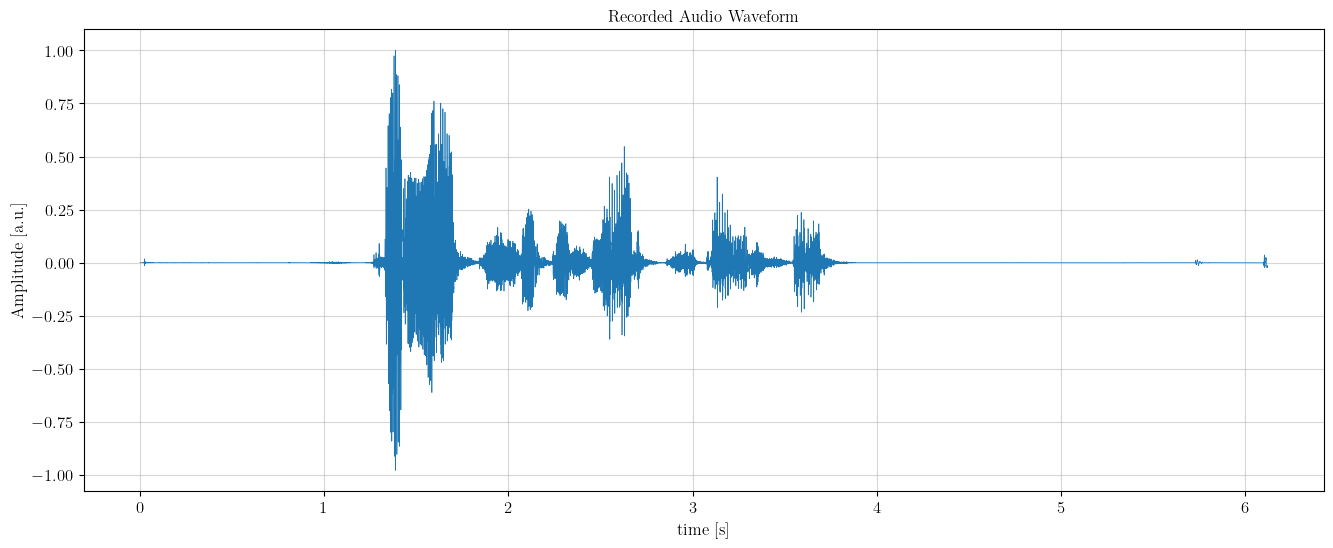

In [ ]:
waveform(VOICE_INPUT, SAMPLING_RATE)

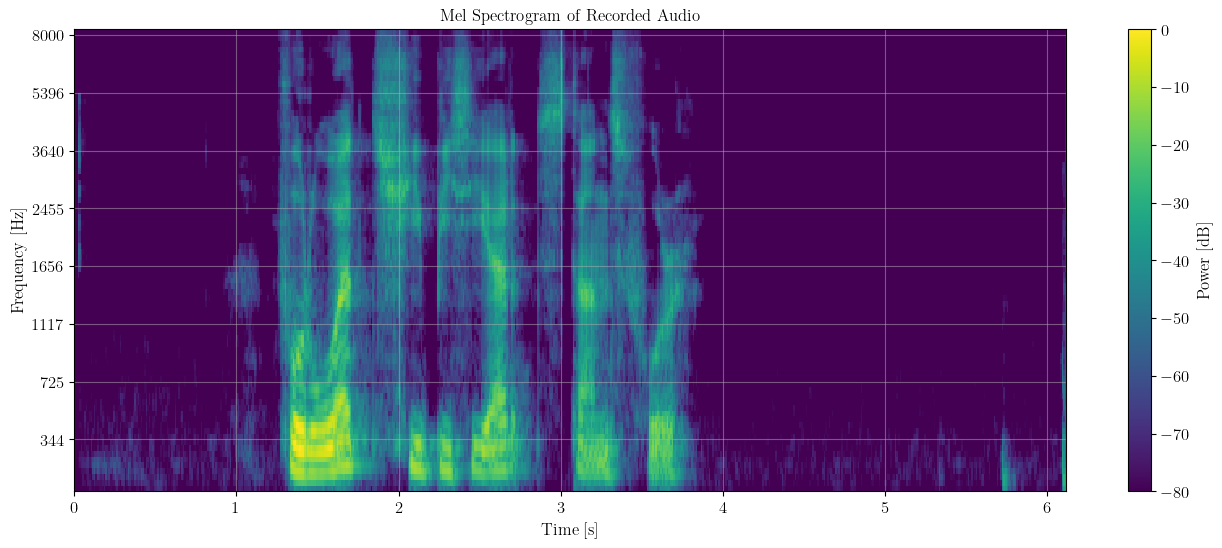

In [ ]:
melSpectrogram(VOICE_INPUT, SAMPLING_RATE)

Now we pass the prompt to the LLM to generate an answer to the question:

In [ ]:
from transformers import pipeline

def llama_prompt_formatter(user_input):
  return f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a helpful medical assistant. You answer truthfully and briefly. Express all numbers exclusively in word form and avoid using digits under any circumstances.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{user_input}<|eot_id|><|start_header_id|>assistant<|end_header_id|>"

pipe = pipeline("text-generation", model=llama_3B_model, tokenizer=llama_3B_tokenizer, return_full_text=False)

prompt = llama_prompt_formatter(TEXT)
SYSTEM_OUTPUT = pipe(prompt, max_new_tokens=1024, num_return_sequences=1, pad_token_id=llama_3B_tokenizer.pad_token_id)[0]["generated_text"]

Device set to use cuda:0
/usr/local/lib/python3.10/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


The model output is as following:

In [ ]:
print(SYSTEM_OUTPUT)



GPCR stands for G Protein-Coupled Receptor.


Lastly, we generate the voice output:

In [ ]:
nlp = spacy.load("en_core_web_sm")  # Load the English language model

doc = nlp(SYSTEM_OUTPUT)

audios = []

# Iterate over sentences
for i, sentence in enumerate(doc.sents):
    txt = sentence.text.replace("*", "")
    txt = txt.strip()
    if txt == "":
      continue
    audio_numpy, sampling_rate = textToSpeech(txt)
    audios.append(audio_numpy)

audio_numpy = np.concatenate(audios, axis=0)
display(Audio(audio_numpy, rate=sampling_rate))

## Voice Chatting with Streamlit

We constructed a chat interface that combines our speech recognition, large language models, and text-to-speech synthesis in an easy to share web application framework.
The web application is managed by Streamlit and Ngrok. Streamlit serves as our frontend and backend framework that is served on port 8501 of the colab instance, while Ngrok is used to make the application available on the internet by creating a public URL that forwards to the local Streamlit server.  

Within the application, the Whisper base model handles speech-to-text conversion by transforming audio into spectrograms, which are then processed into text. To enhance precision, the model is focused on English, and its outputs are cached directly by the Streamlit application.

LLaMA is our core reasoning engine. We're using our fine-tunned version on flashcards with 3B parameters to generate the answers to the questions. However, the model can easily be changed by replacing the model name in the app script.

The text-to-speech is managed by Microsoft's SpeechT5. First, it loads the base SpeechT5 model through the Hugging Face pipeline, then it uses x-vectors (voice embeddings) from the CMU Arctic dataset to define the voice characteristics and finally, we process text sentence by sentence. As mentioned before, all of this happens while Streamlit manages the web interface and state, keeping the models loaded in memory (thanks to @st.cache_resource) for quick responses.

We also use Streamlit's session state to manage the models and the tokenizer, keep a session conversational history and UI state management, as for example, the recording action.

Notice it is essential to provide an authorization key from an Ngrok account. For this -> log in ngrok.com -> then go to your auth token: https://dashboard.ngrok.com/get-started/your-authtoken

In addition, when the link is generated, it will be of the form: "https://{num}.ngrok-free.app" . The loading of each model will take a few minutes. It also necessary to login in HF as done at the beginning of the notebook and to add the secret key for Ngrok as mentioned above. The script is importing the model parameters and tokenizer from the "./llama-3B_flashcards" directory. Therefore, this directory should contain the respective files.
We can modify the model to use, the max limit of tokens generated, different voices, languages, the size of the whisper model, among other variables.

In [ ]:

!pip install --upgrade --quiet streamlit>=1.5
!apt-get update -qq && apt-get install -y ffmpeg
!pip install -q pyngrok openai-whisper soundfile librosa audio-recorder-streamlit
!pip install -q transformers datasets

import subprocess
import time
from pyngrok import ngrok

print("Done installing. Checking Streamlit:")
import streamlit as st
print("Streamlit version:", st.__version__)

#########################################
# ngrok Auth
#########################################
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
#NGROK_AUTH_TOKEN = "IF NOT INSERT TOKEN HERE"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

app_code = r"""
import streamlit as st
import time
import torch
import whisper
import librosa
import soundfile as sf
import base64
import io
import os
import re

from audio_recorder_streamlit import audio_recorder
from transformers import (
    pipeline as tts_pipeline,
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from datasets import load_dataset

@st.cache_resource
def load_finetuned_model():
    # PASS THE PATH TO THE FINE TUNED MODEL WE CARE ABOUT
    model_name = "./llama-3B_flashcards"
    quant_conf = BitsAndBytesConfig(load_in_8bit=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = "[PAD]"
        tokenizer.add_special_tokens({"pad_token": "[PAD]"})

    if torch.cuda.is_available():
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            quantization_config=quant_conf,
            torch_dtype=torch.float16
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            quantization_config=quant_conf,
            torch_dtype=torch.float32
        )
    return model, tokenizer

@st.cache_resource
def load_whisper():
    return whisper.load_model("base")

@st.cache_resource
def load_speechT5():
    synth = tts_pipeline("text-to-speech", model="microsoft/speecht5_tts")
    ds = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
    spk = torch.tensor(ds[7306]["xvector"]).unsqueeze(0)
    return synth, spk

def sentence_split(text):
    text = text.replace("*", "").replace("\n", " ")
    parts = re.split(r"([.?!])", text)
    sents = []
    buffer = ""
    for c in parts:
        if c in [".", "?", "!"]:
            buffer += c
            sents.append(buffer.strip())
            buffer = ""
        else:
            buffer += c
    if buffer.strip():
        sents.append(buffer.strip())
    return [s.strip() for s in sents if s.strip()]

def text_to_speech(txt, synth, emb):
    if not txt.strip():
        return None
    import numpy as np
    segments = []
    sr = 22050
    for seg in sentence_split(txt):
        out = synth(seg, forward_params={"speaker_embeddings": emb})
        audio_np = out["audio"]
        sr = out["sampling_rate"]
        segments.append(audio_np)
    final_audio = np.concatenate(segments, axis=0)
    import io
    with io.BytesIO() as buf:
        sf.write(buf, final_audio, sr, format="WAV")
        wav_data = buf.getvalue()
    return wav_data

def process_audio(audio_bytes):
    import tempfile
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name
    arr, _ = librosa.load(tmp_path, sr=16000, mono=True)
    os.unlink(tmp_path)
    return arr

def transcribe_audio(audio_arr, wmodel):
    try:
        res = wmodel.transcribe(
            audio_arr,
            language='en',
            task='transcribe',
            fp16=False
        )
        return res["text"].strip()
    except Exception as e:
        st.error(f"Error transcribing: {e}")
        return ""

def generate_response(user_text):
    model = st.session_state.get("ft_model")
    tokenizer = st.session_state.get("ft_tokenizer")
    if not model or not tokenizer:
        return "Error: No fine-tuned model loaded."

    prompt = (
        "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
        "You are a direct and efficient medical assistant. Provide brief, actionable advice. "
        "Express all numbers exclusively in word form and avoid using digits under any circumstances."
        "<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n"
        f"{user_text}<|eot_id|><|start_header_id|>assistant<|end_header_id|>"
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    pad_id = tokenizer.pad_token_id
    out = model.generate(
        **inputs,
        max_new_tokens=256,
        pad_token_id=pad_id,
        do_sample=True,
        temperature=0.6,
        top_p=0.85,
        top_k=40,
        early_stopping=True
    )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    if user_text in decoded:
        splitted = decoded.split(user_text + "assistant", 1)
        if len(splitted) > 1:
            decoded = splitted[-1].strip()
    return decoded

def main():
    st.set_page_config(page_title="Med Voice Assistant", layout="wide")
    st.title("🏥 Medical Voice Assistant")

    # first load the fine tuned model and the whisper model
    if "ft_model" not in st.session_state or "ft_tokenizer" not in st.session_state:
        with st.spinner("Loading fine-tuned LLaMA..."):
            m, t = load_finetuned_model()
            st.session_state["ft_model"] = m
            st.session_state["ft_tokenizer"] = t

    if "whisper_model" not in st.session_state:
        with st.spinner("Loading Whisper..."):
            st.session_state["whisper_model"] = load_whisper()

    if "synth" not in st.session_state:
        with st.spinner("Loading SpeechT5..."):
            s5, emb = load_speechT5()
            st.session_state["synth"] = s5
            st.session_state["emb"] = emb

    # init the states
    if "messages" not in st.session_state:
        st.session_state["messages"] = []

    if "recorder_key" not in st.session_state:
        st.session_state["recorder_key"] = 0

    # sidebar
    with st.sidebar:
        if st.button("Clear Chat"):
            st.session_state["messages"] = []
            st.session_state["recorder_key"] = 0
        st.markdown('''
        ### How to Use
        1. Click "Record" once to start, click again to stop
        2. Immediately see text + TTS
        3. Wait for the response, then recorder will be ready again
        ''')

    # conversation history
    for msg in st.session_state["messages"]:
        with st.chat_message(msg["role"]):
            st.write(msg["content"])
            if msg.get("audio"):
                if msg["role"] == "assistant":
                    b64 = base64.b64encode(msg["audio"]).decode()
                    audio_html = f'''
                    <audio controls autoplay onended="window.location.reload();">
                      <source src="data:audio/wav;base64,{b64}" type="audio/wav">
                    </audio>
                    '''
                    st.markdown(audio_html, unsafe_allow_html=True)
                else:
                    st.audio(msg["audio"], format="audio/wav")

    # voice input
    st.write("#### 🎤 Voice Input")
    st.info("Single click to start, single click to stop")

    recorder_key = f"rec_{st.session_state['recorder_key']}"

    audio_bytes = audio_recorder(
        text="Record",
        recording_color="#e74c3c",
        neutral_color="#3498db",
        energy_threshold=0.01,
        pause_threshold=1.0,
        key=recorder_key
    )

    if audio_bytes and len(audio_bytes) > 1000:
        st.write("**Log**: Processing your question now...")
        arr = process_audio(audio_bytes)

        with st.spinner("Transcribing..."):
            user_text = transcribe_audio(arr, st.session_state["whisper_model"])

        if user_text:
            # messages displaying
            with st.chat_message("user"):
                st.write(user_text)
                st.audio(audio_bytes, format="audio/wav")

            st.session_state["messages"].append({
                "role": "user",
                "content": user_text,
                "audio": audio_bytes
            })

            # response generation
            with st.spinner("Generating LLaMA response..."):
                answer_text = generate_response(user_text)

            with st.spinner("Synthesizing TTS..."):
                wav_data = text_to_speech(answer_text, st.session_state["synth"], st.session_state["emb"])

            with st.chat_message("assistant"):
                st.write(answer_text)
                if wav_data:
                    b64a = base64.b64encode(wav_data).decode()
                    audio_html = f'''
                    <audio controls autoplay onended="window.location.reload();">
                      <source src="data:audio/wav;base64,{b64a}" type="audio/wav"/>
                    </audio>
                    '''
                    st.markdown(audio_html, unsafe_allow_html=True)

            st.session_state["messages"].append({
                "role": "assistant",
                "content": answer_text,
                "audio": wav_data
            })

            st.session_state["recorder_key"] += 1
            st.rerun()

    typed = st.chat_input("Or type your question here...")
    if typed:
        with st.chat_message("user"):
            st.write(typed)
        st.session_state["messages"].append({"role": "user", "content": typed})

        with st.spinner("Generating LLaMA response..."):
            ans_txt = generate_response(typed)
        with st.spinner("Synthesizing TTS..."):
            ans_wav = text_to_speech(ans_txt, st.session_state["synth"], st.session_state["emb"])

        with st.chat_message("assistant"):
            st.write(ans_txt)
            if ans_wav:
                b64b = base64.b64encode(ans_wav).decode()
                st.markdown(f'''
                <audio controls autoplay onended="window.location.reload();">
                  <source src="data:audio/wav;base64,{b64b}" type="audio/wav">
                </audio>
                ''', unsafe_allow_html=True)

        st.session_state["messages"].append({
            "role": "assistant",
            "content": ans_txt,
            "audio": ans_wav
        })

        st.session_state["recorder_key"] += 1
        st.rerun()

if __name__ == "__main__":
    main()
"""


with open("app.py", "w") as f:
    f.write(app_code)

print("app.py successfully written.")


# run Streamlit + ngrok

!pkill -f streamlit || echo "No existing streamlit"
!pkill -f ngrok || echo "No existing ngrok"

print("Starting Streamlit on port 8501...")

proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

time.sleep(5)
print("Connecting ngrok...")

try:
    ngrok.kill()
    tunnel = ngrok.connect(8501, "http")
    print(f"\nNgrok public URL: {tunnel}\n")
    print("Open this link in a new browser tab.")
except Exception as e:
    print("ngrok error:", e)
    proc.terminate()

# we need to keep the cell alive to use it as server
try:
    while True:
        out_line = proc.stdout.readline()
        if out_line:
            print("[STREAMLIT-LOG]", out_line, end="")
        err_line = proc.stderr.readline()
        if err_line:
            print("[STREAMLIT-ERR]", err_line, end="")
        if proc.poll() is not None:
            print("\nStreamlit ended.")
            break
        time.sleep(1)

except KeyboardInterrupt:
    print("\nKeyboardInterrupt -> shutting down.")
    proc.terminate()
    ngrok.kill()
finally:
    proc.terminate()
    ngrok.kill()
    print("Done.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.
Done installing. Checking Streamlit:
Streamlit version: 1.41.1
app.py successfully written.
^C
^C
Starting Streamlit on port 8501...
Connecting ngrok...

Ngrok public URL: NgrokTunnel: "https://49eb-35-198-221-170.ngrok-free.app" -> "http://localhost:8501"

Open this link in a new browser tab.
[STREAMLIT-LOG] 
[STREAMLIT-ERR] 2025-01-06 01:20:37.671981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
[STREAMLIT-LOG] Collecting usage statistics. To